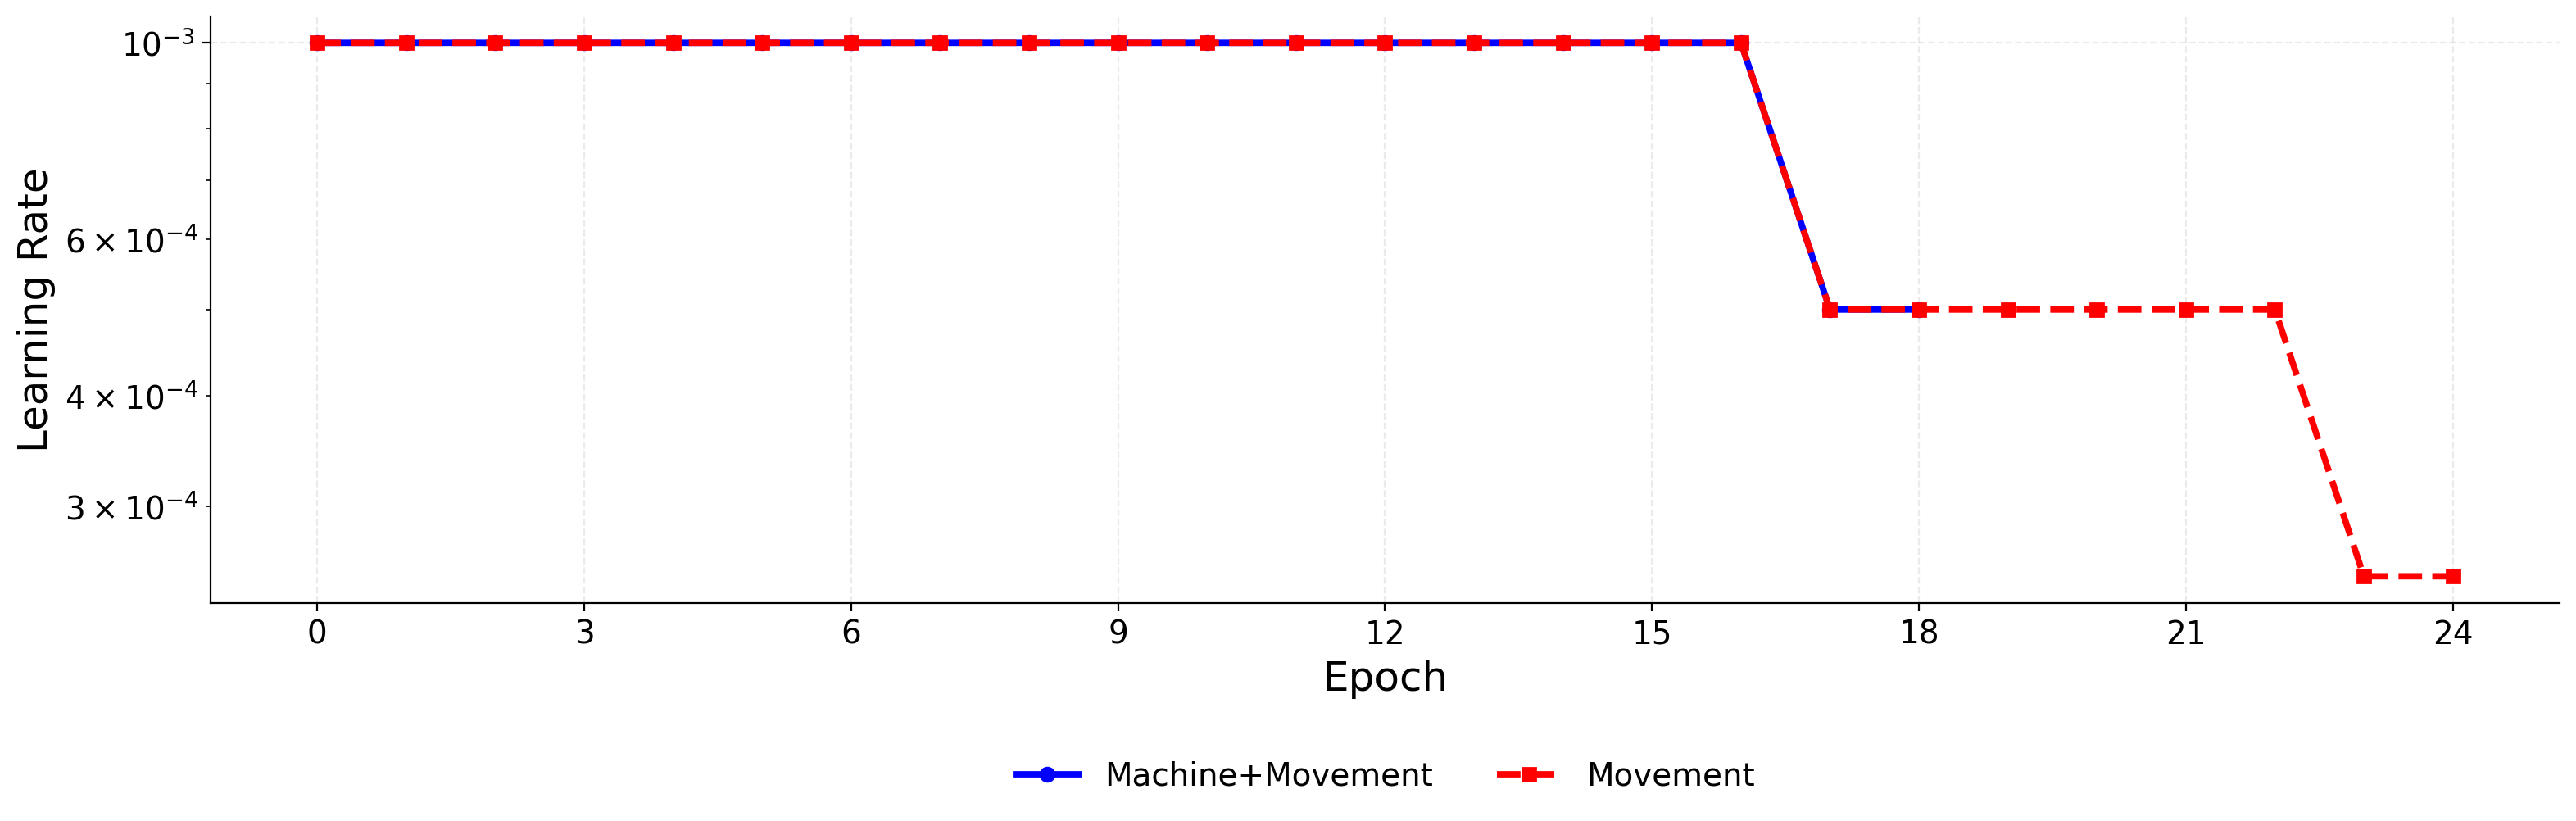

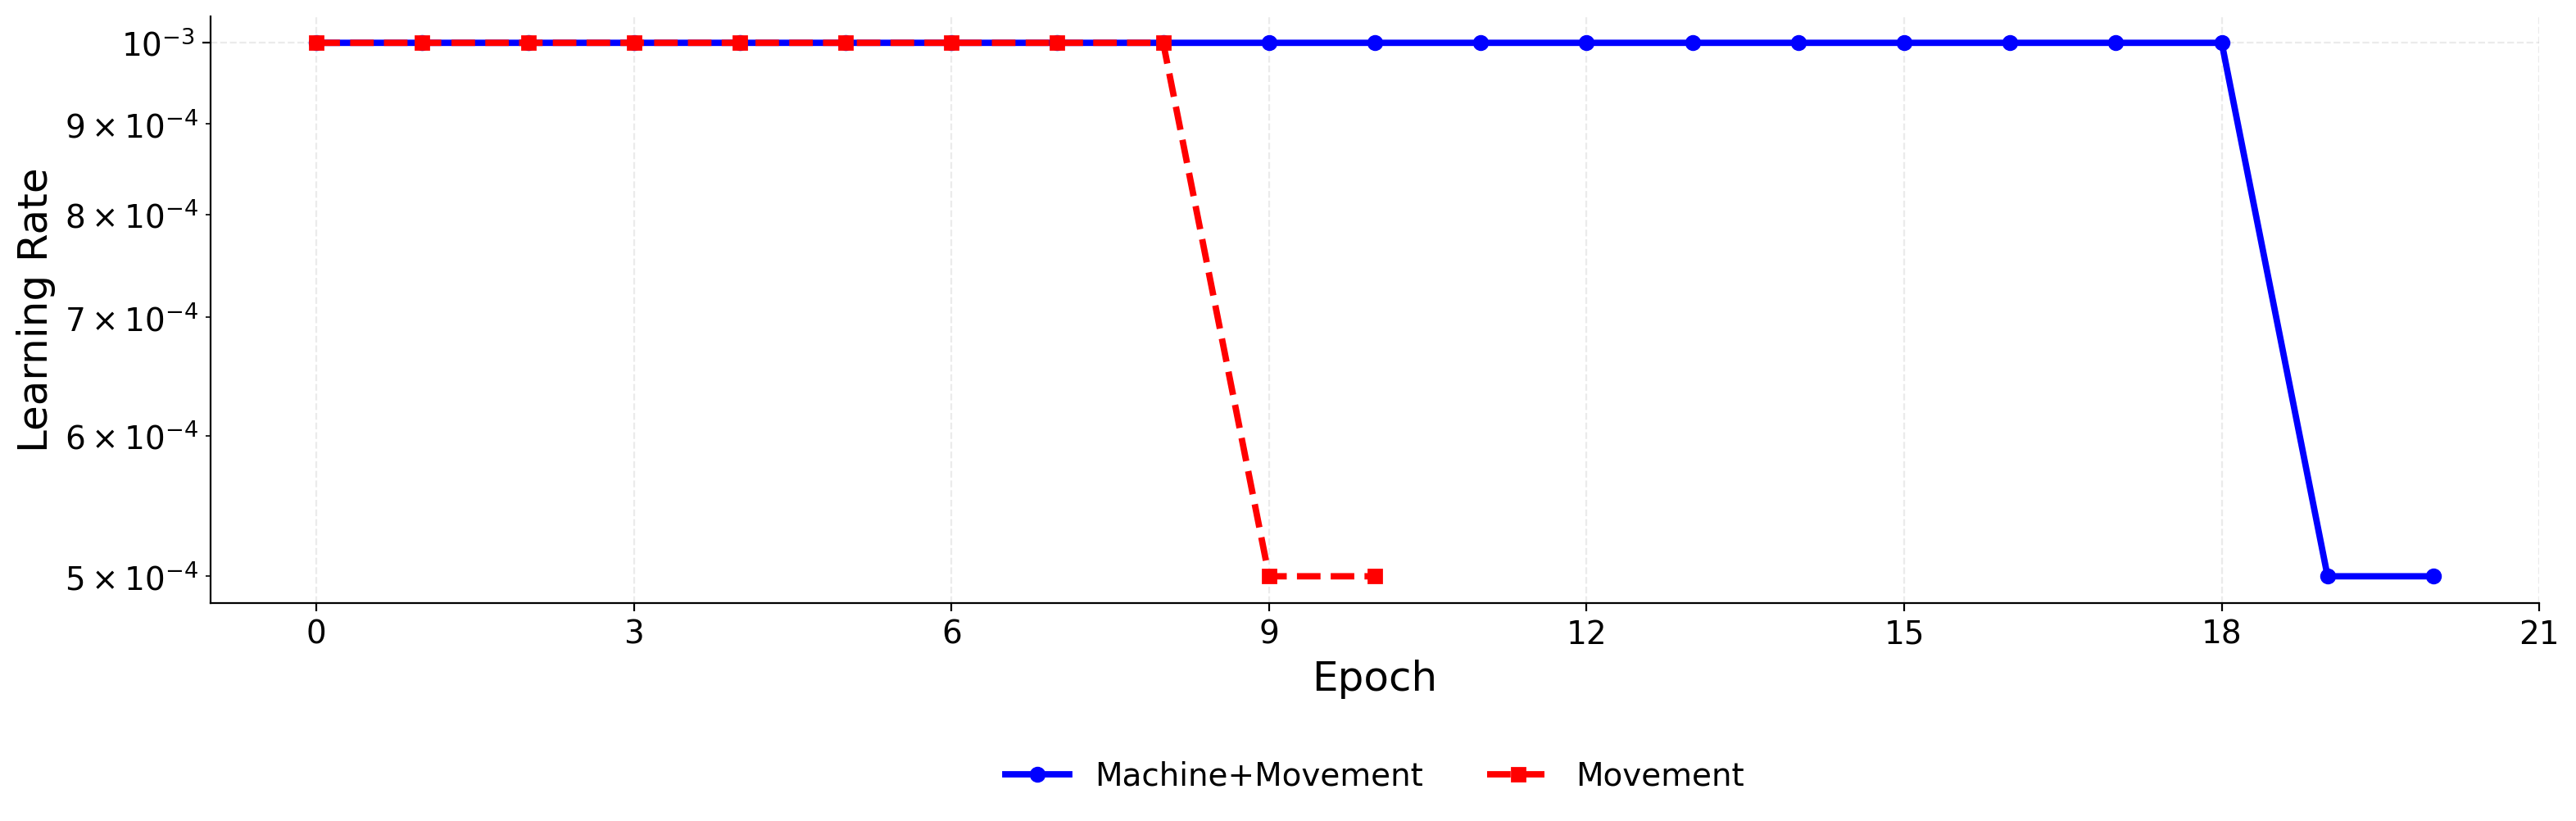

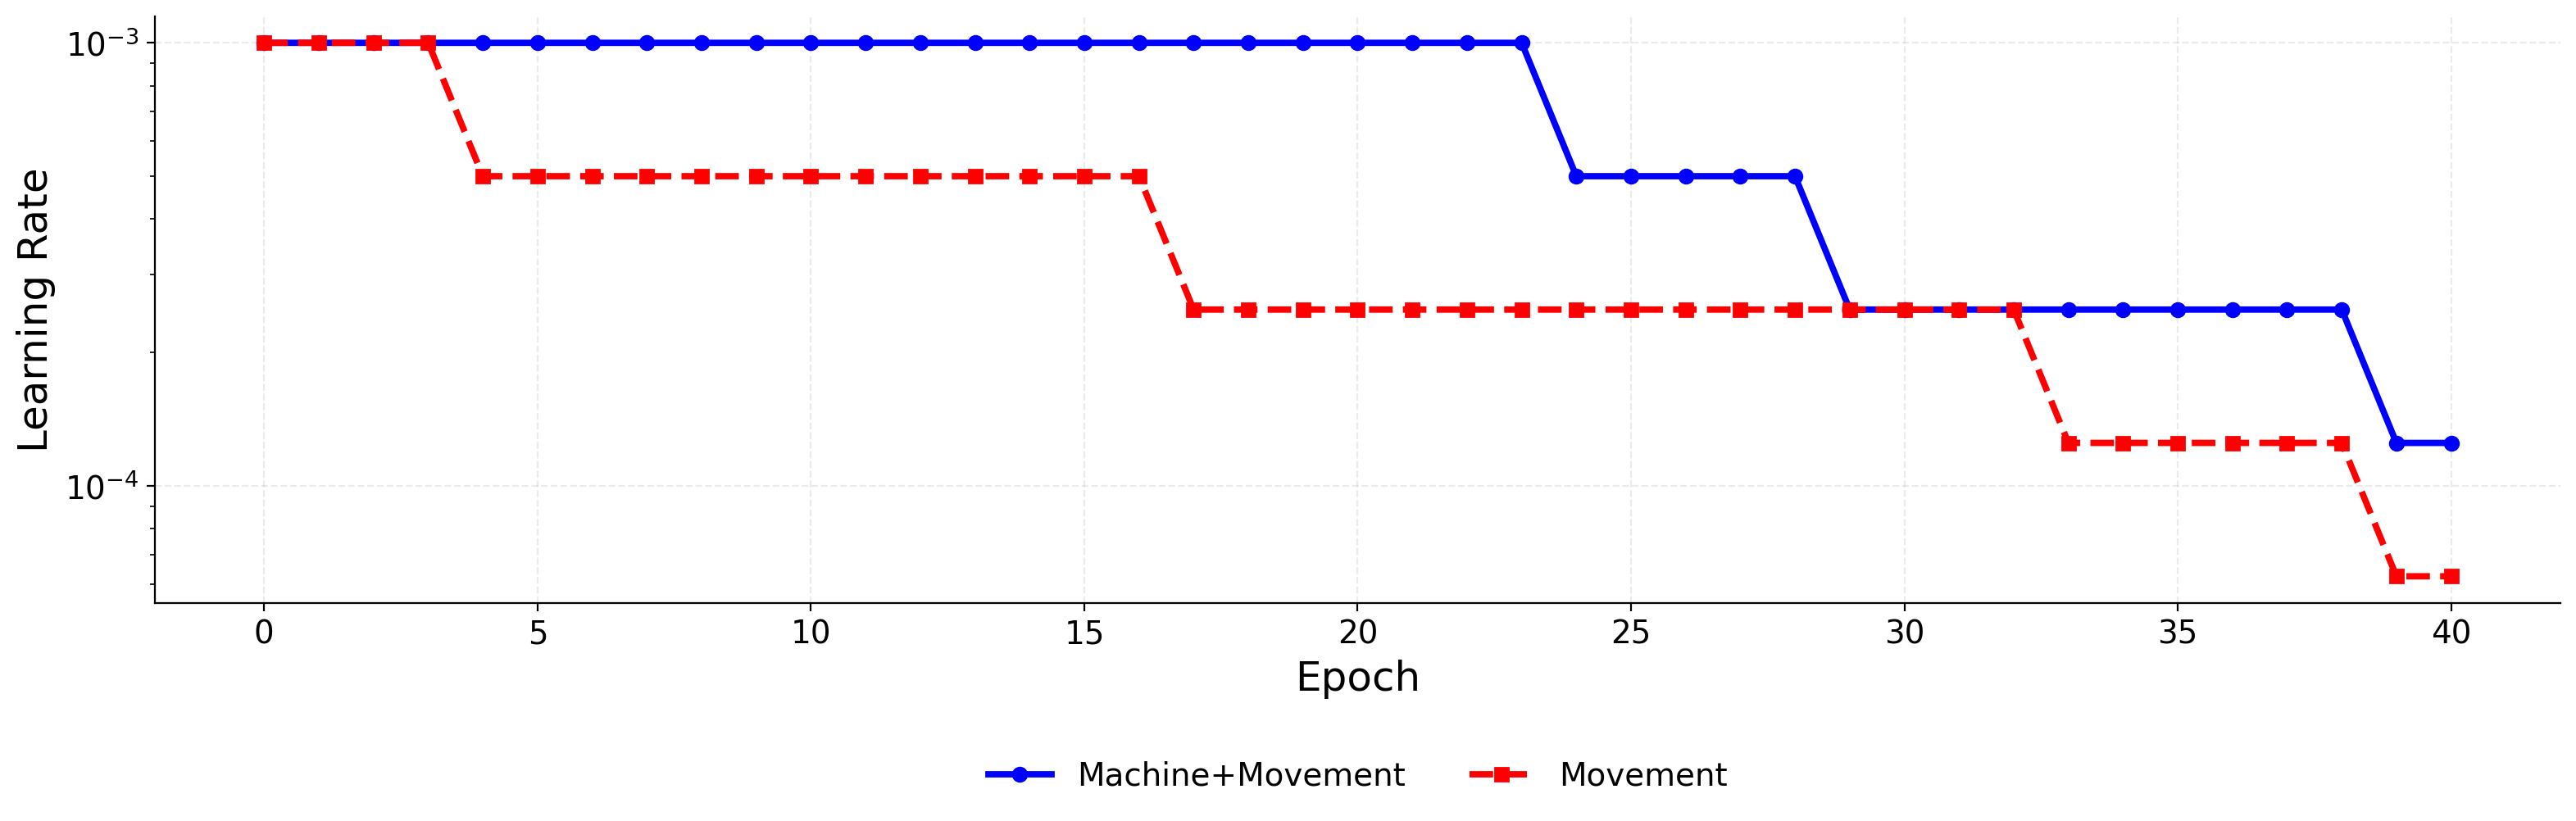

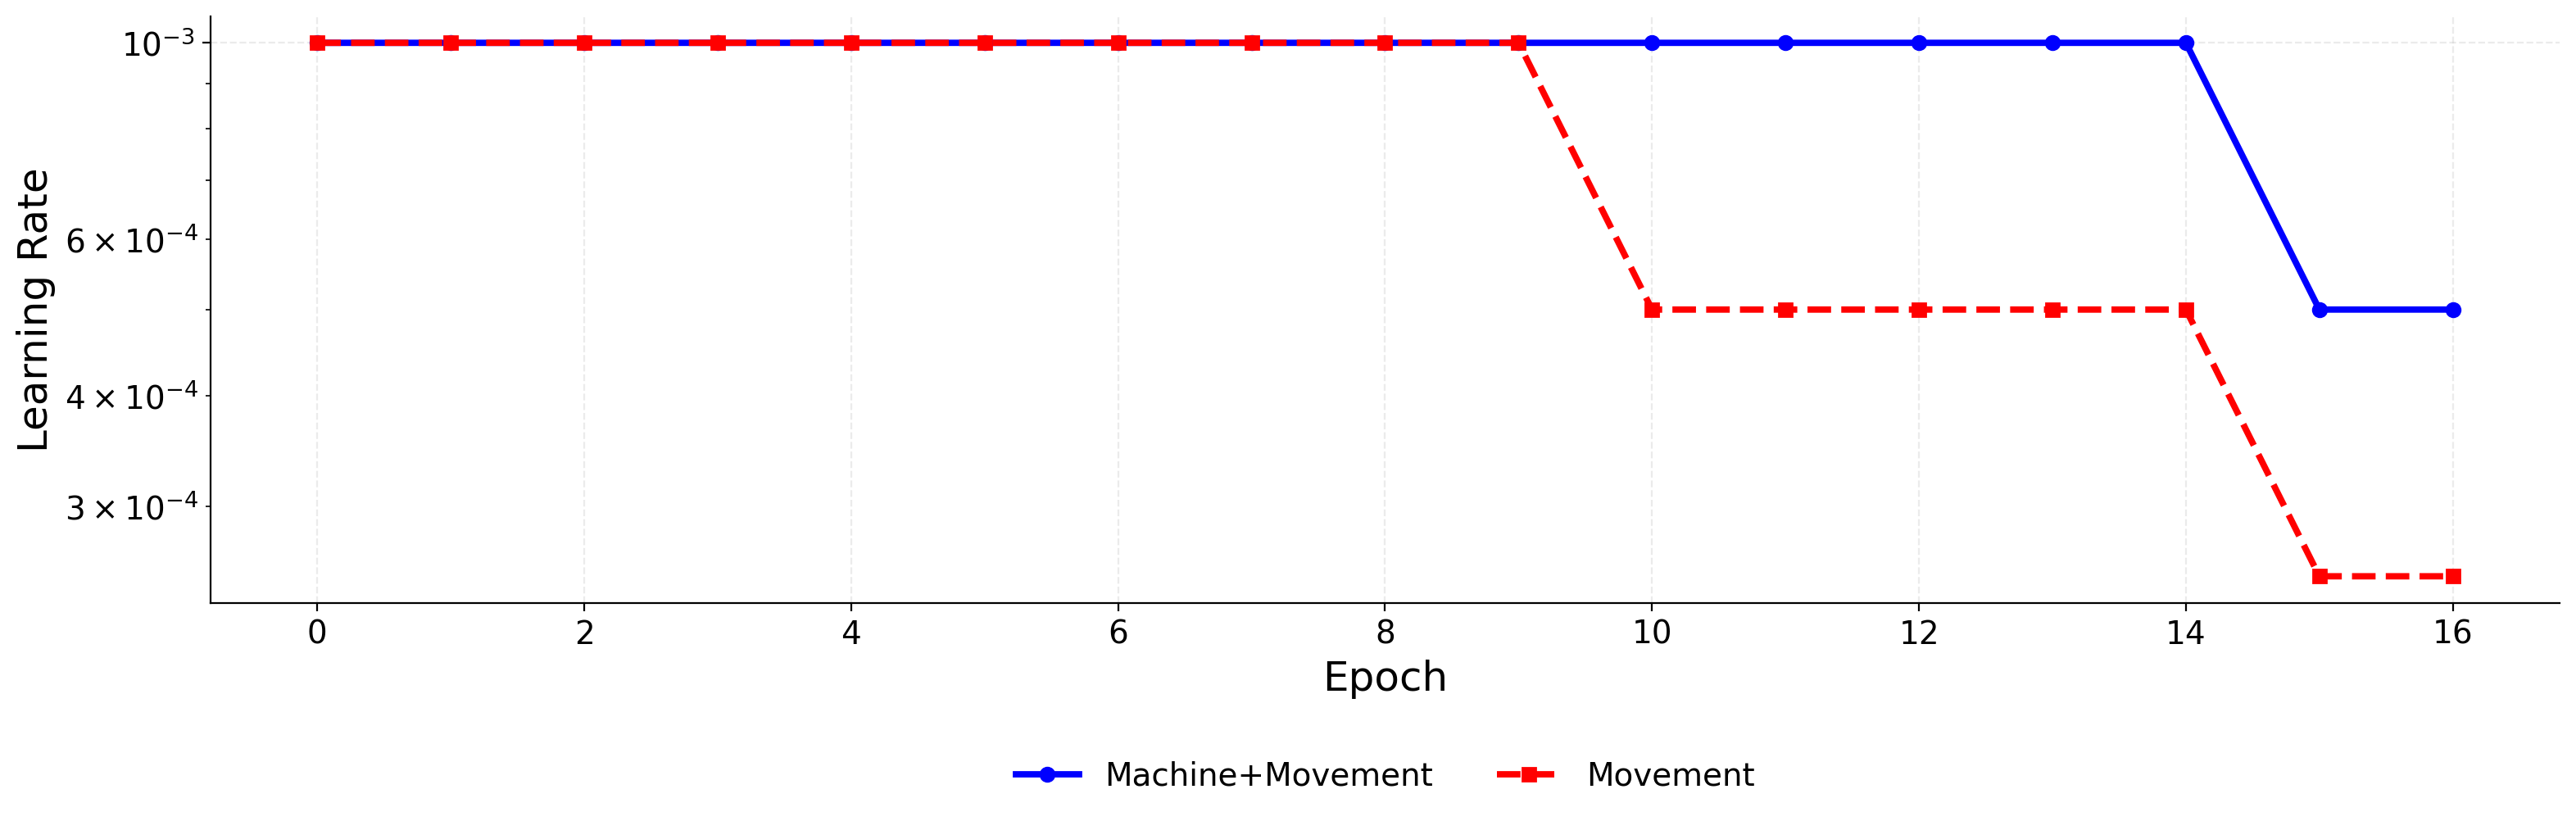

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# =====================================
# Paths
# =====================================
root_dir = "results/activity_recognition"

experiment_folders = {
    "Machine+Movement": os.path.join(root_dir, "machine_and_movement"),
    "Movement": os.path.join(root_dir, "movement"),
}

output_dir = root_dir
show_plot = True
save_plot = True

process_part_order = [
    "All",
    "Bending",
    "Clamping",
    "De-Clamping",
    "Mandrel Extraction",
]

# =====================================
# Plot style
# =====================================
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 2.8,
    "lines.markersize": 6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# =====================================
# Helpers
# =====================================
def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")


def find_learning_rate_file(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    for file_path in csv_files:
        try:
            test_df = pd.read_csv(file_path, nrows=50)
            if "metric" in test_df.columns and (test_df["metric"] == "learning_rate_current").any():
                return file_path
        except Exception:
            continue

    return None


def load_learning_rate_csv(file_path):

    df = pd.read_csv(file_path)

    df = df[df["metric"] == "learning_rate_current"].copy()

    df["step"] = pd.to_numeric(df["step"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

    df = df.drop_duplicates()
    df = df.dropna(subset=["Run", "step", "value"])

    if "timestamp" in df.columns:
        df = df.sort_values(["Run", "step", "timestamp"])
    else:
        df = df.sort_values(["Run", "step"])

    df = df.drop_duplicates(subset=["Run", "step"], keep="first")

    return df


# =====================================
# Load data
# =====================================
all_lr_data = {}
all_runs = set()

for exp_name, exp_dir in experiment_folders.items():

    lr_file = find_learning_rate_file(exp_dir)

    if lr_file is None:
        continue

    df = load_learning_rate_csv(lr_file)

    if df.empty:
        continue

    all_lr_data[exp_name] = df
    all_runs.update(df["Run"].unique())


ordered_runs = [r for r in process_part_order if r in all_runs]
ordered_runs += [r for r in sorted(all_runs) if r not in ordered_runs]


# =====================================
# Colors
# =====================================
styles = {
    "Machine+Movement": {"linestyle": "-", "marker": "o", "color": "blue"},
    "Movement": {"linestyle": "--", "marker": "s", "color": "red"},
}


# =====================================
# Plot
# =====================================
for run_name in ordered_runs:

    fig, ax = plt.subplots(figsize=(16, 6))

    positive_values = []

    for exp_name in ["Machine+Movement", "Movement"]:

        if exp_name not in all_lr_data:
            continue

        df = all_lr_data[exp_name]
        run_df = df[df["Run"] == run_name]

        if run_df.empty:
            continue

        style = styles[exp_name]

        ax.plot(
            run_df["step"],
            run_df["value"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            label=exp_name
        )

        positive_values.extend(
            [v for v in run_df["value"].tolist() if pd.notna(v) and v > 0]
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    if positive_values:
        ax.set_yscale("log")

    # Legend bottom center (slightly lower)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=2,
        frameon=False
    )

    # Layout adjusted so legend fits
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    if save_plot:
        output_path = os.path.join(
            output_dir,
            f"learning_rate_{safe_name(run_name)}.pdf"
        )
        plt.savefig(output_path, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

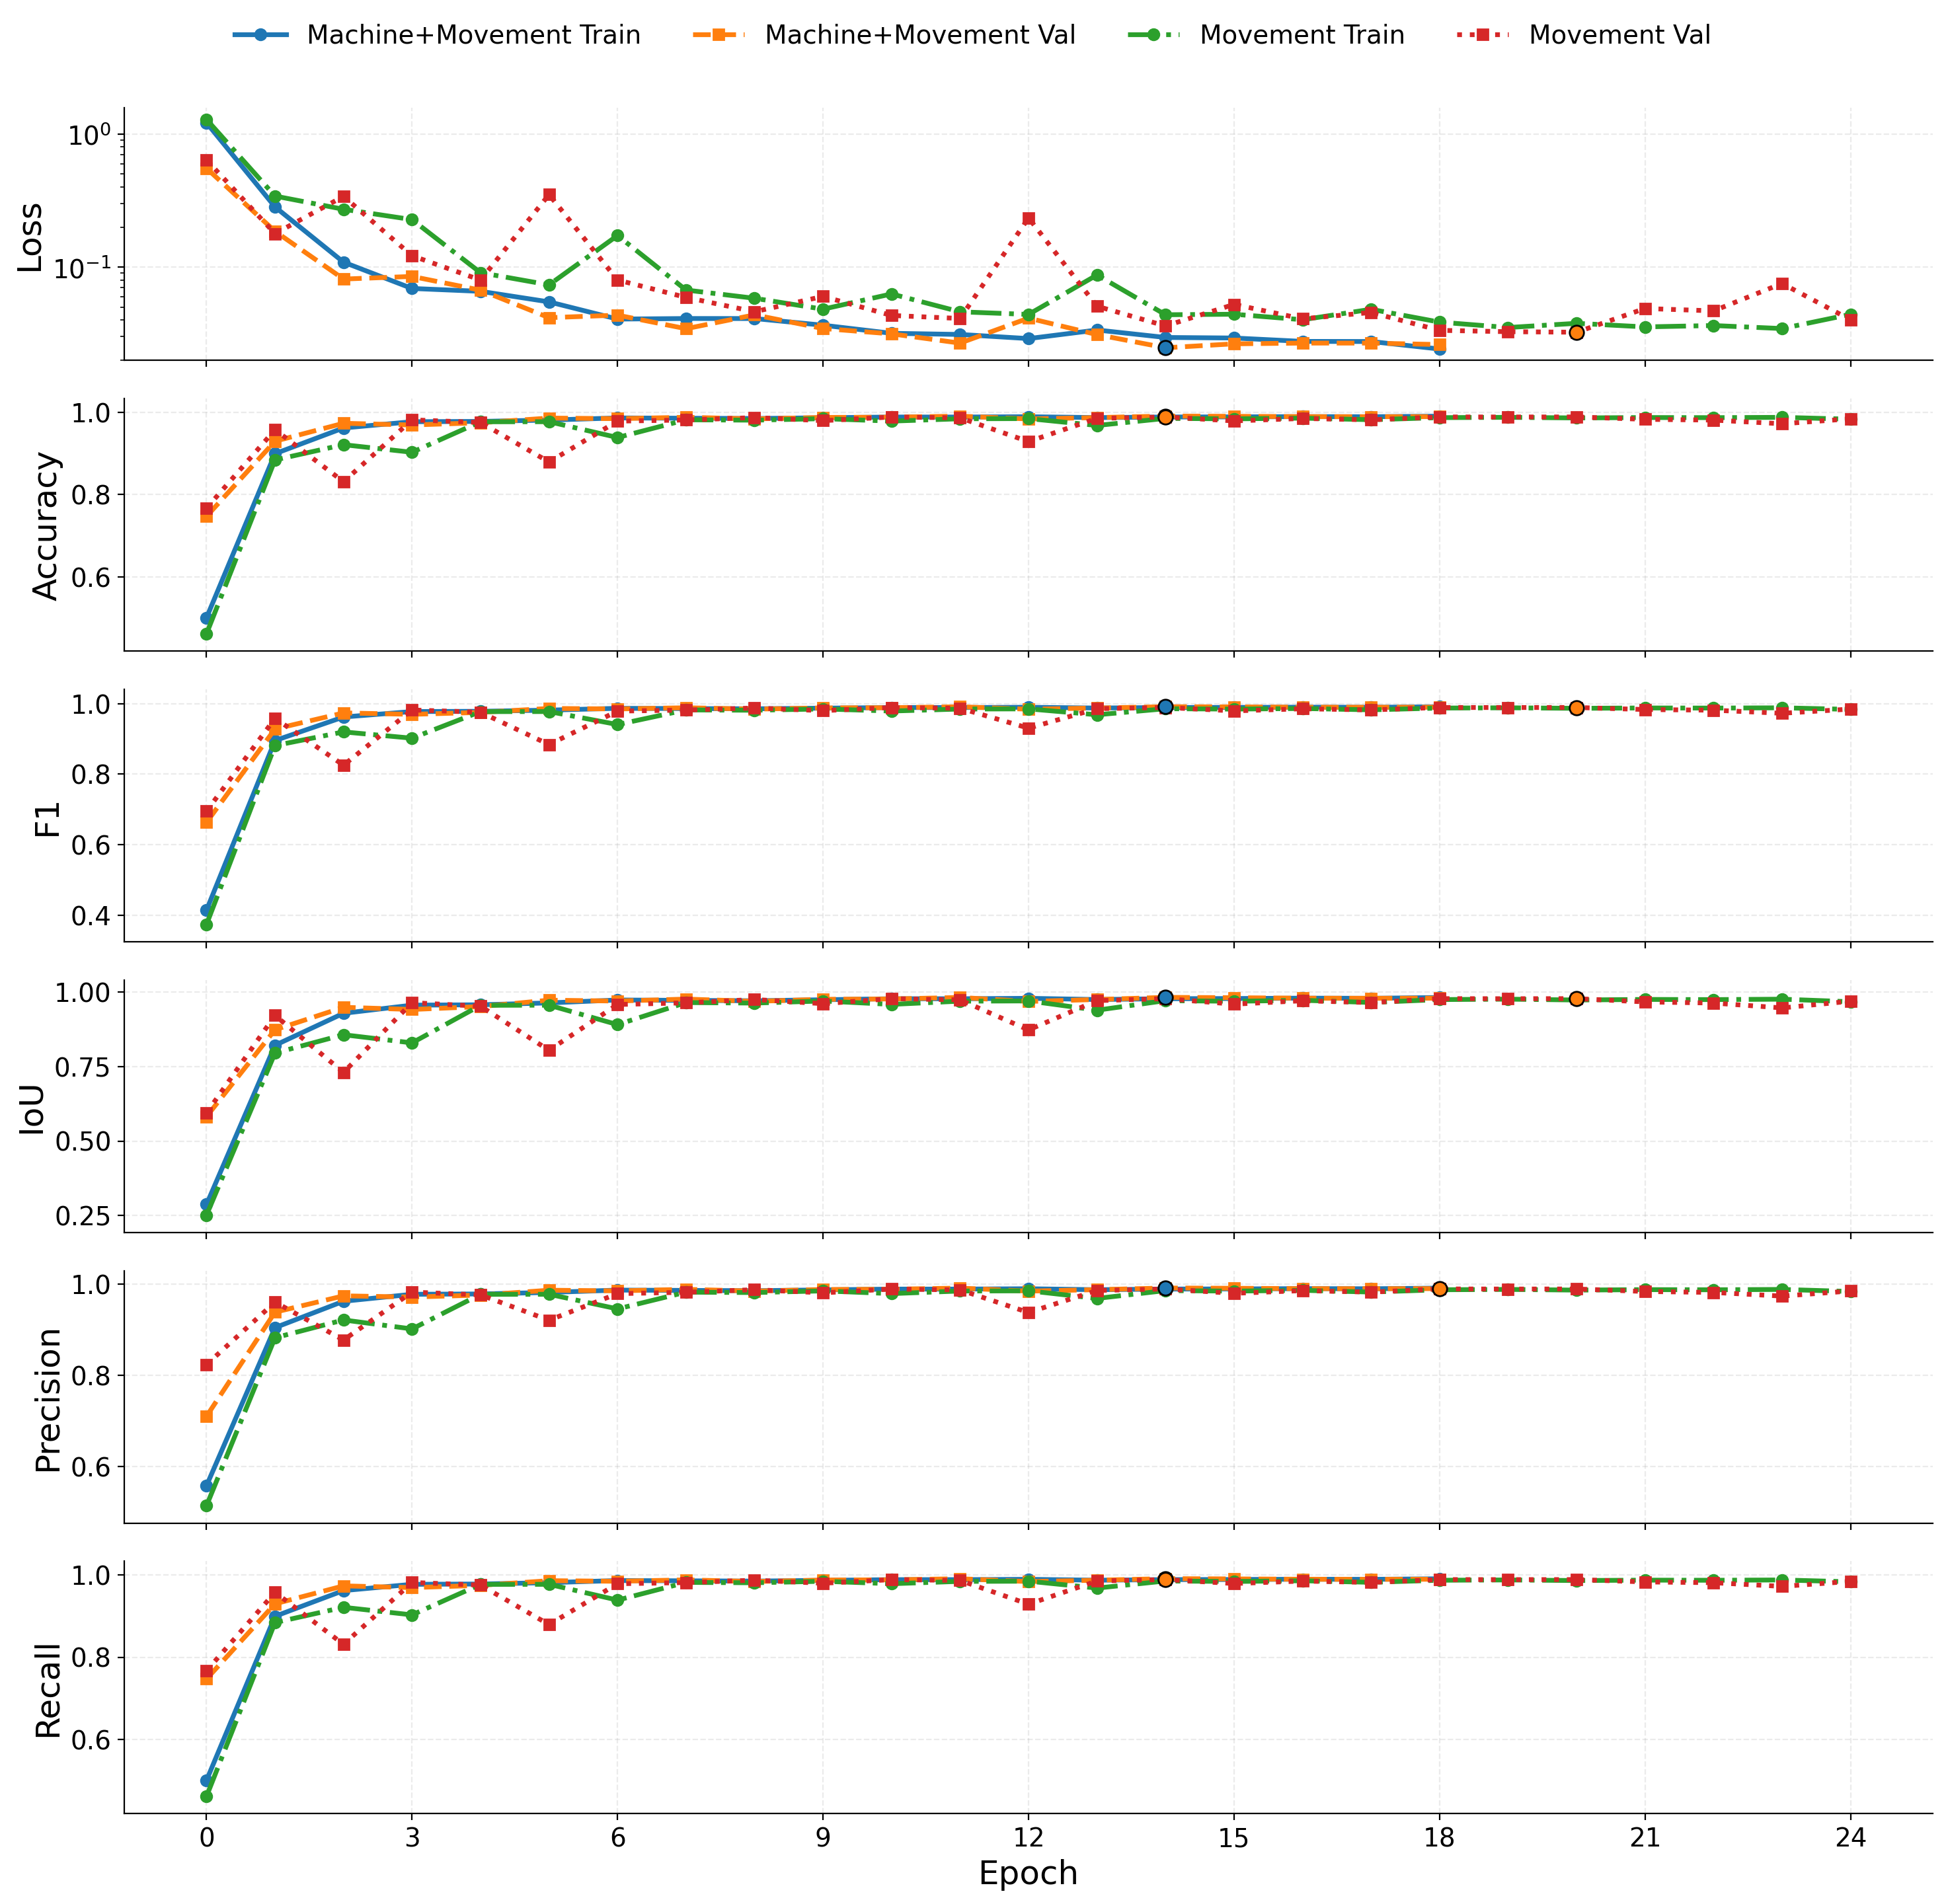

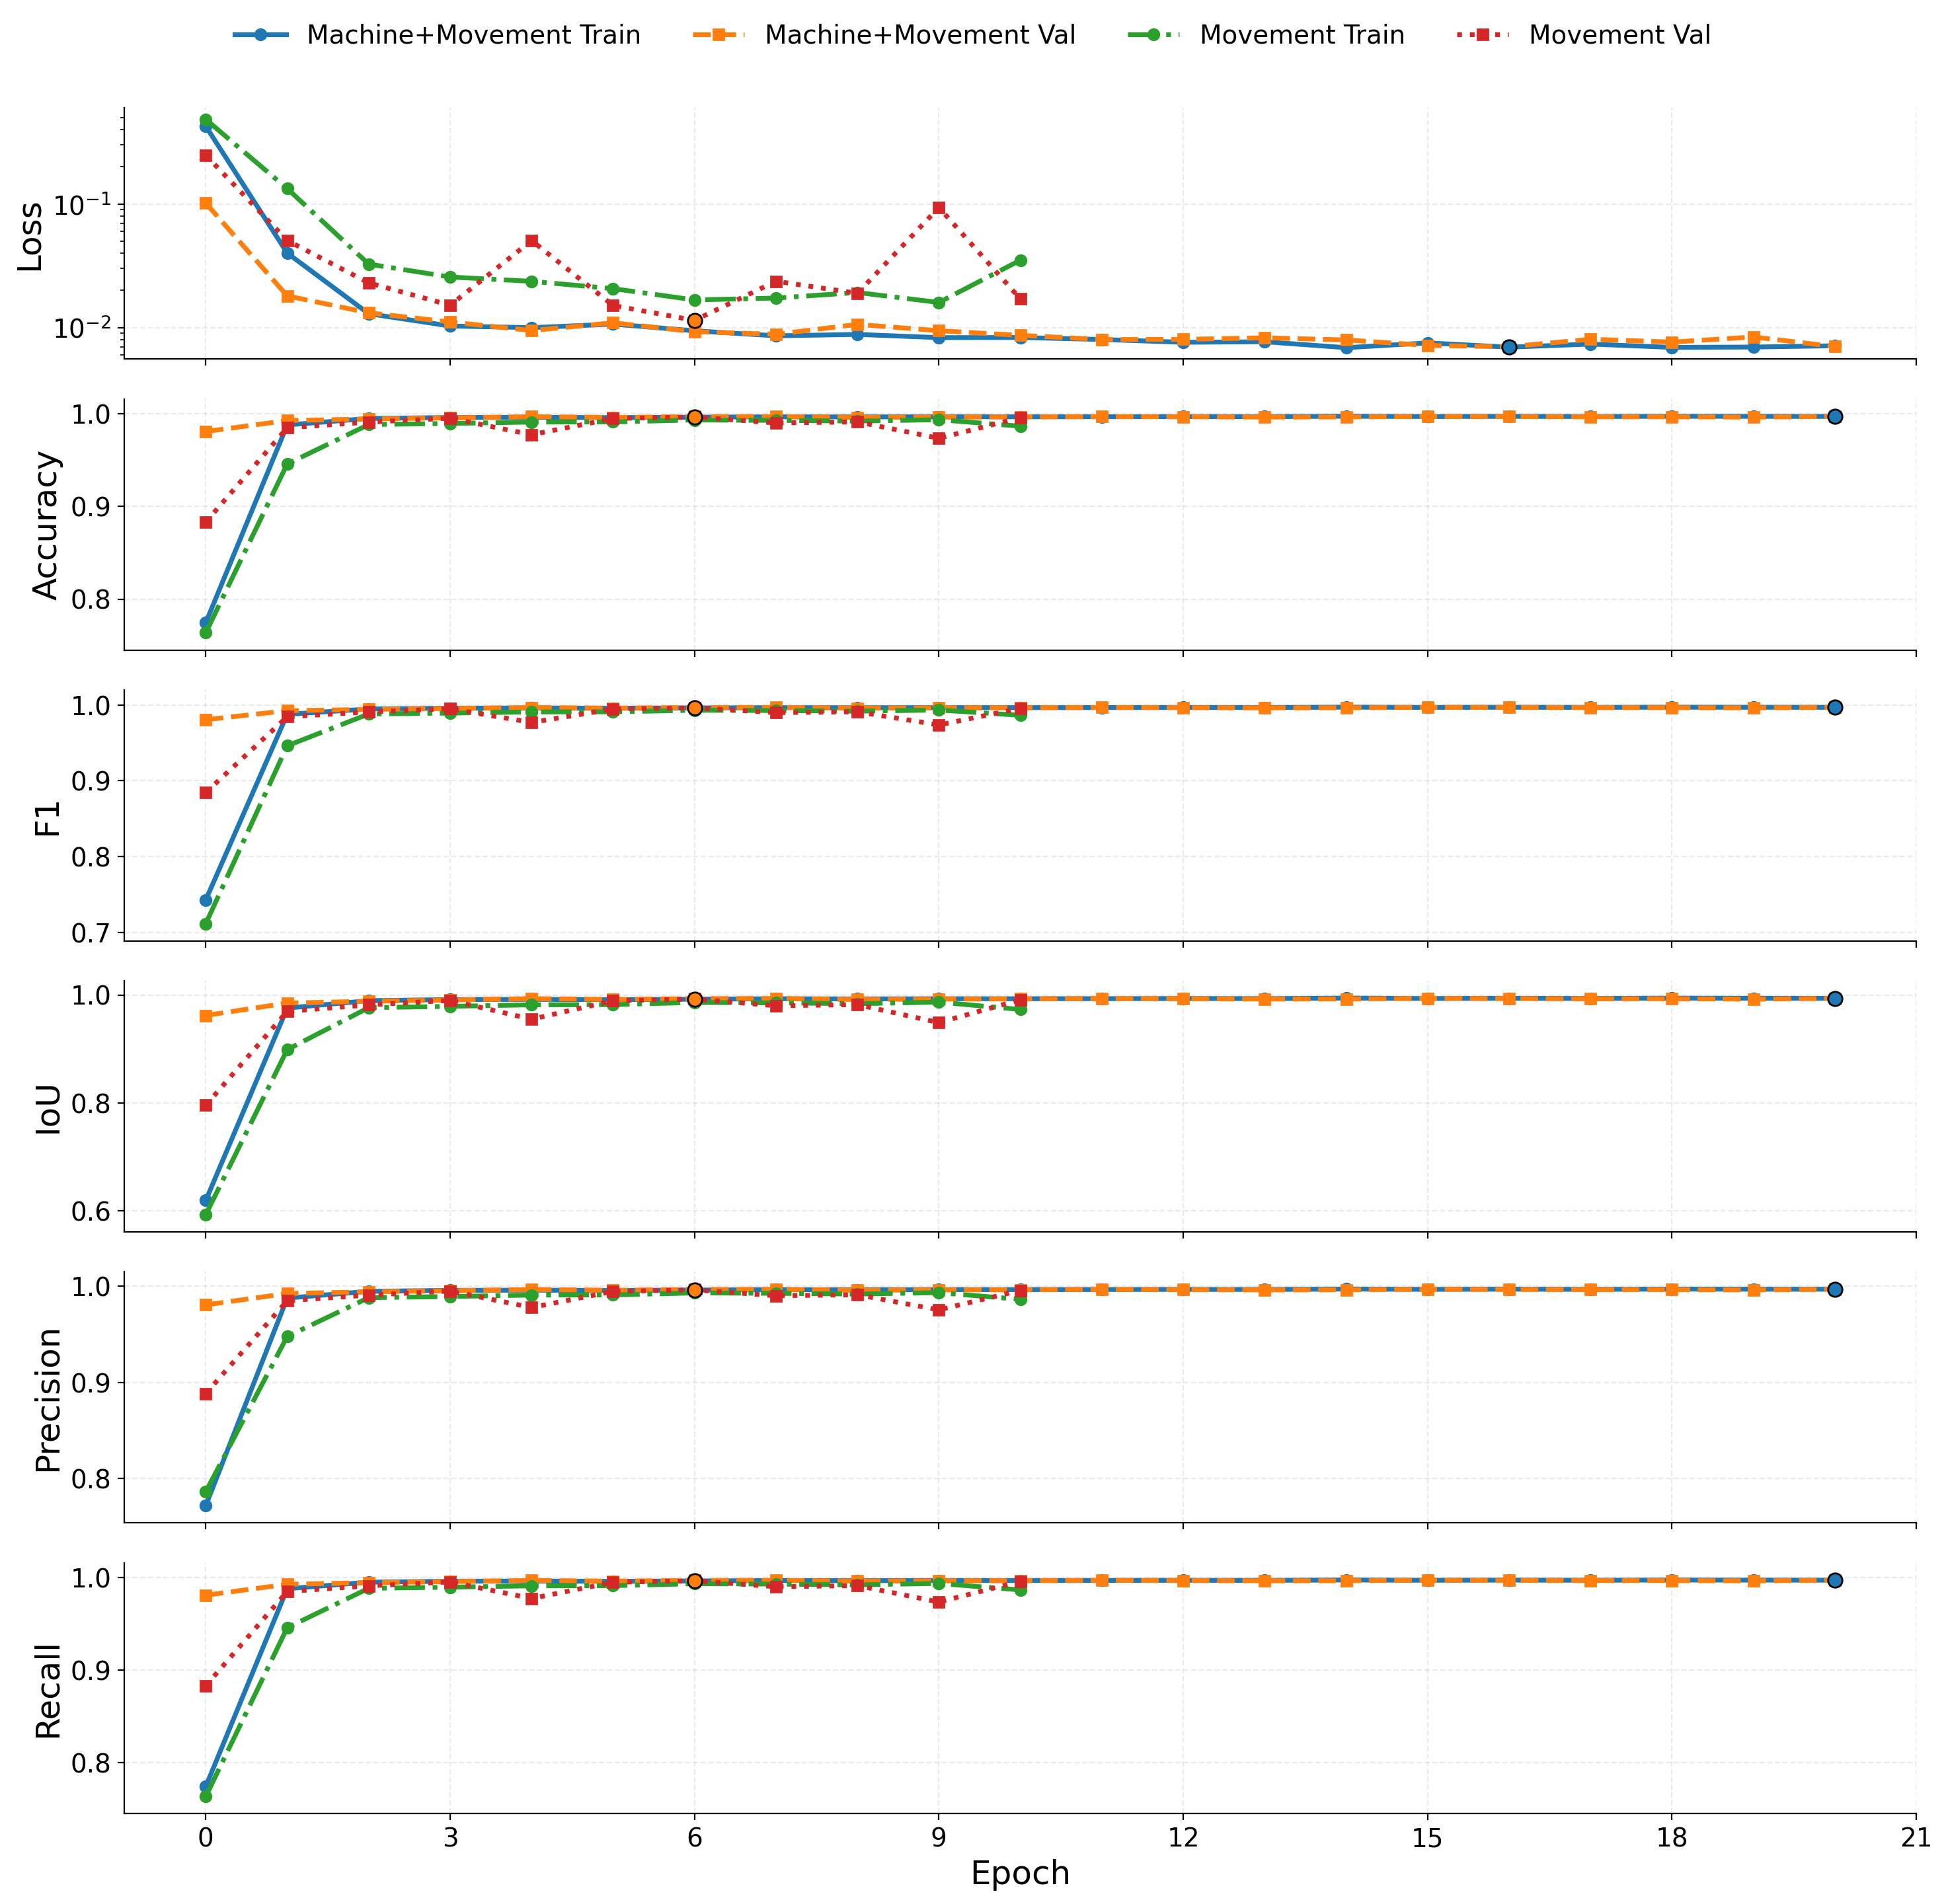

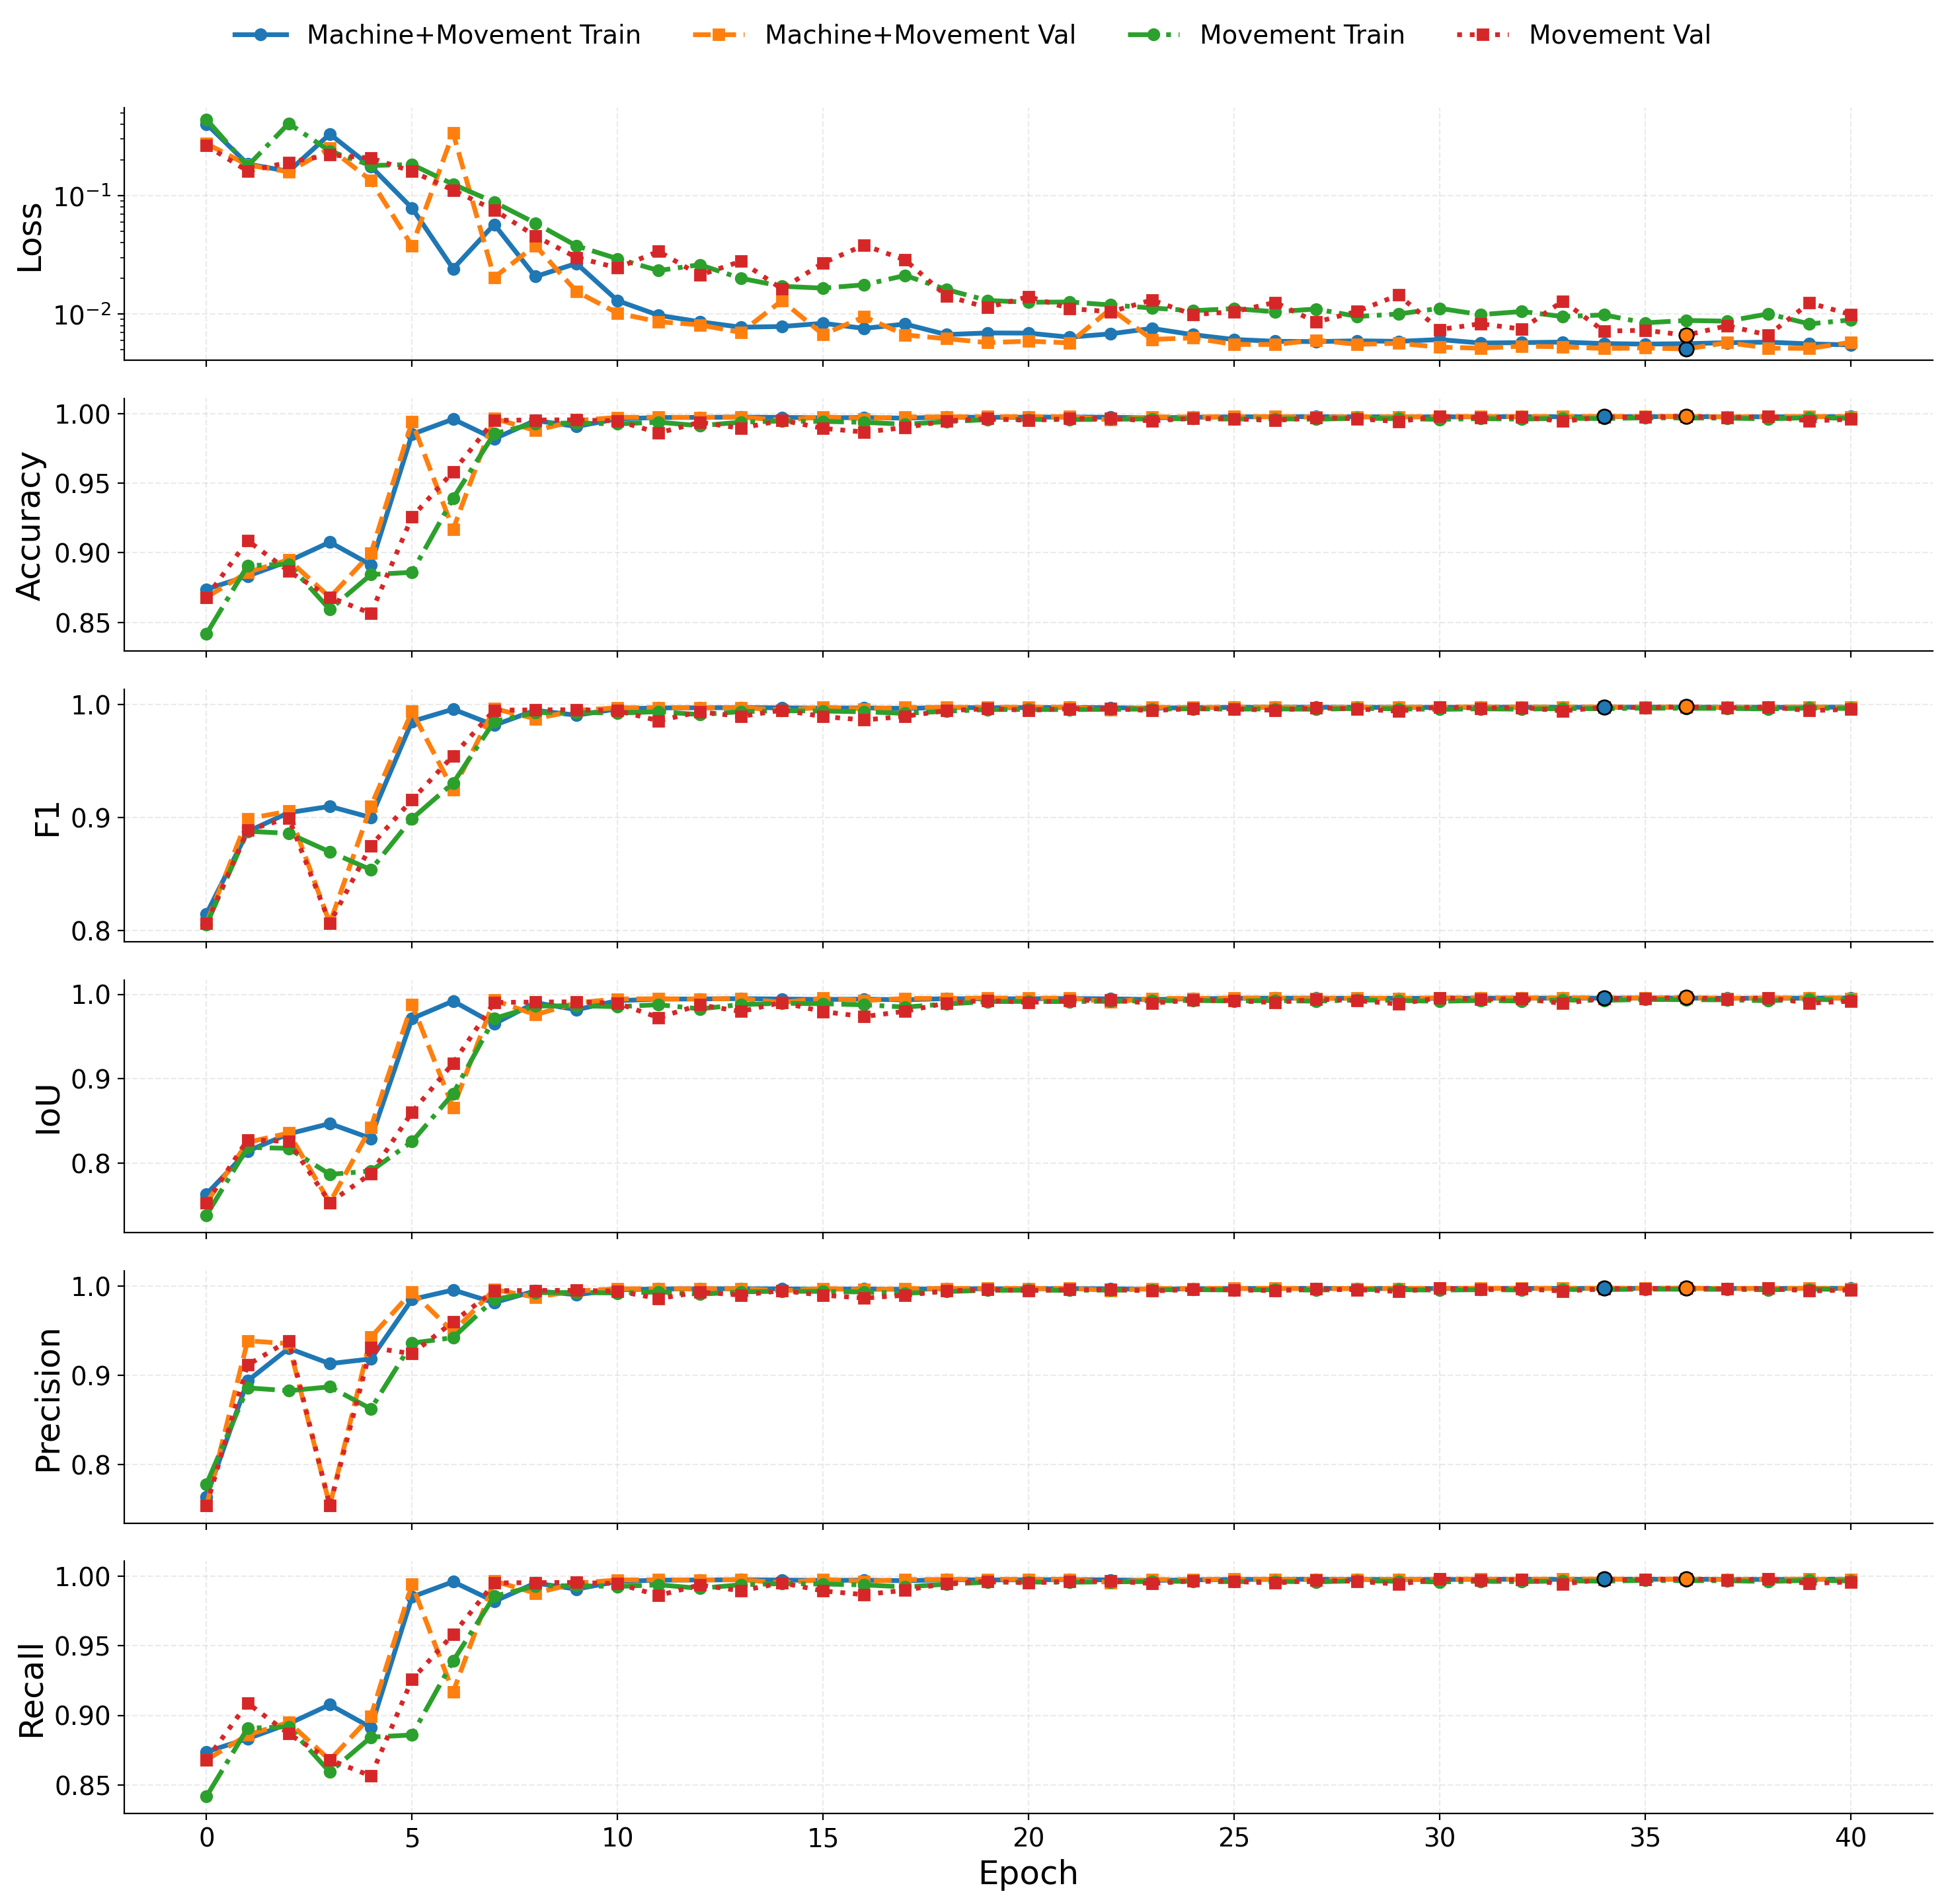

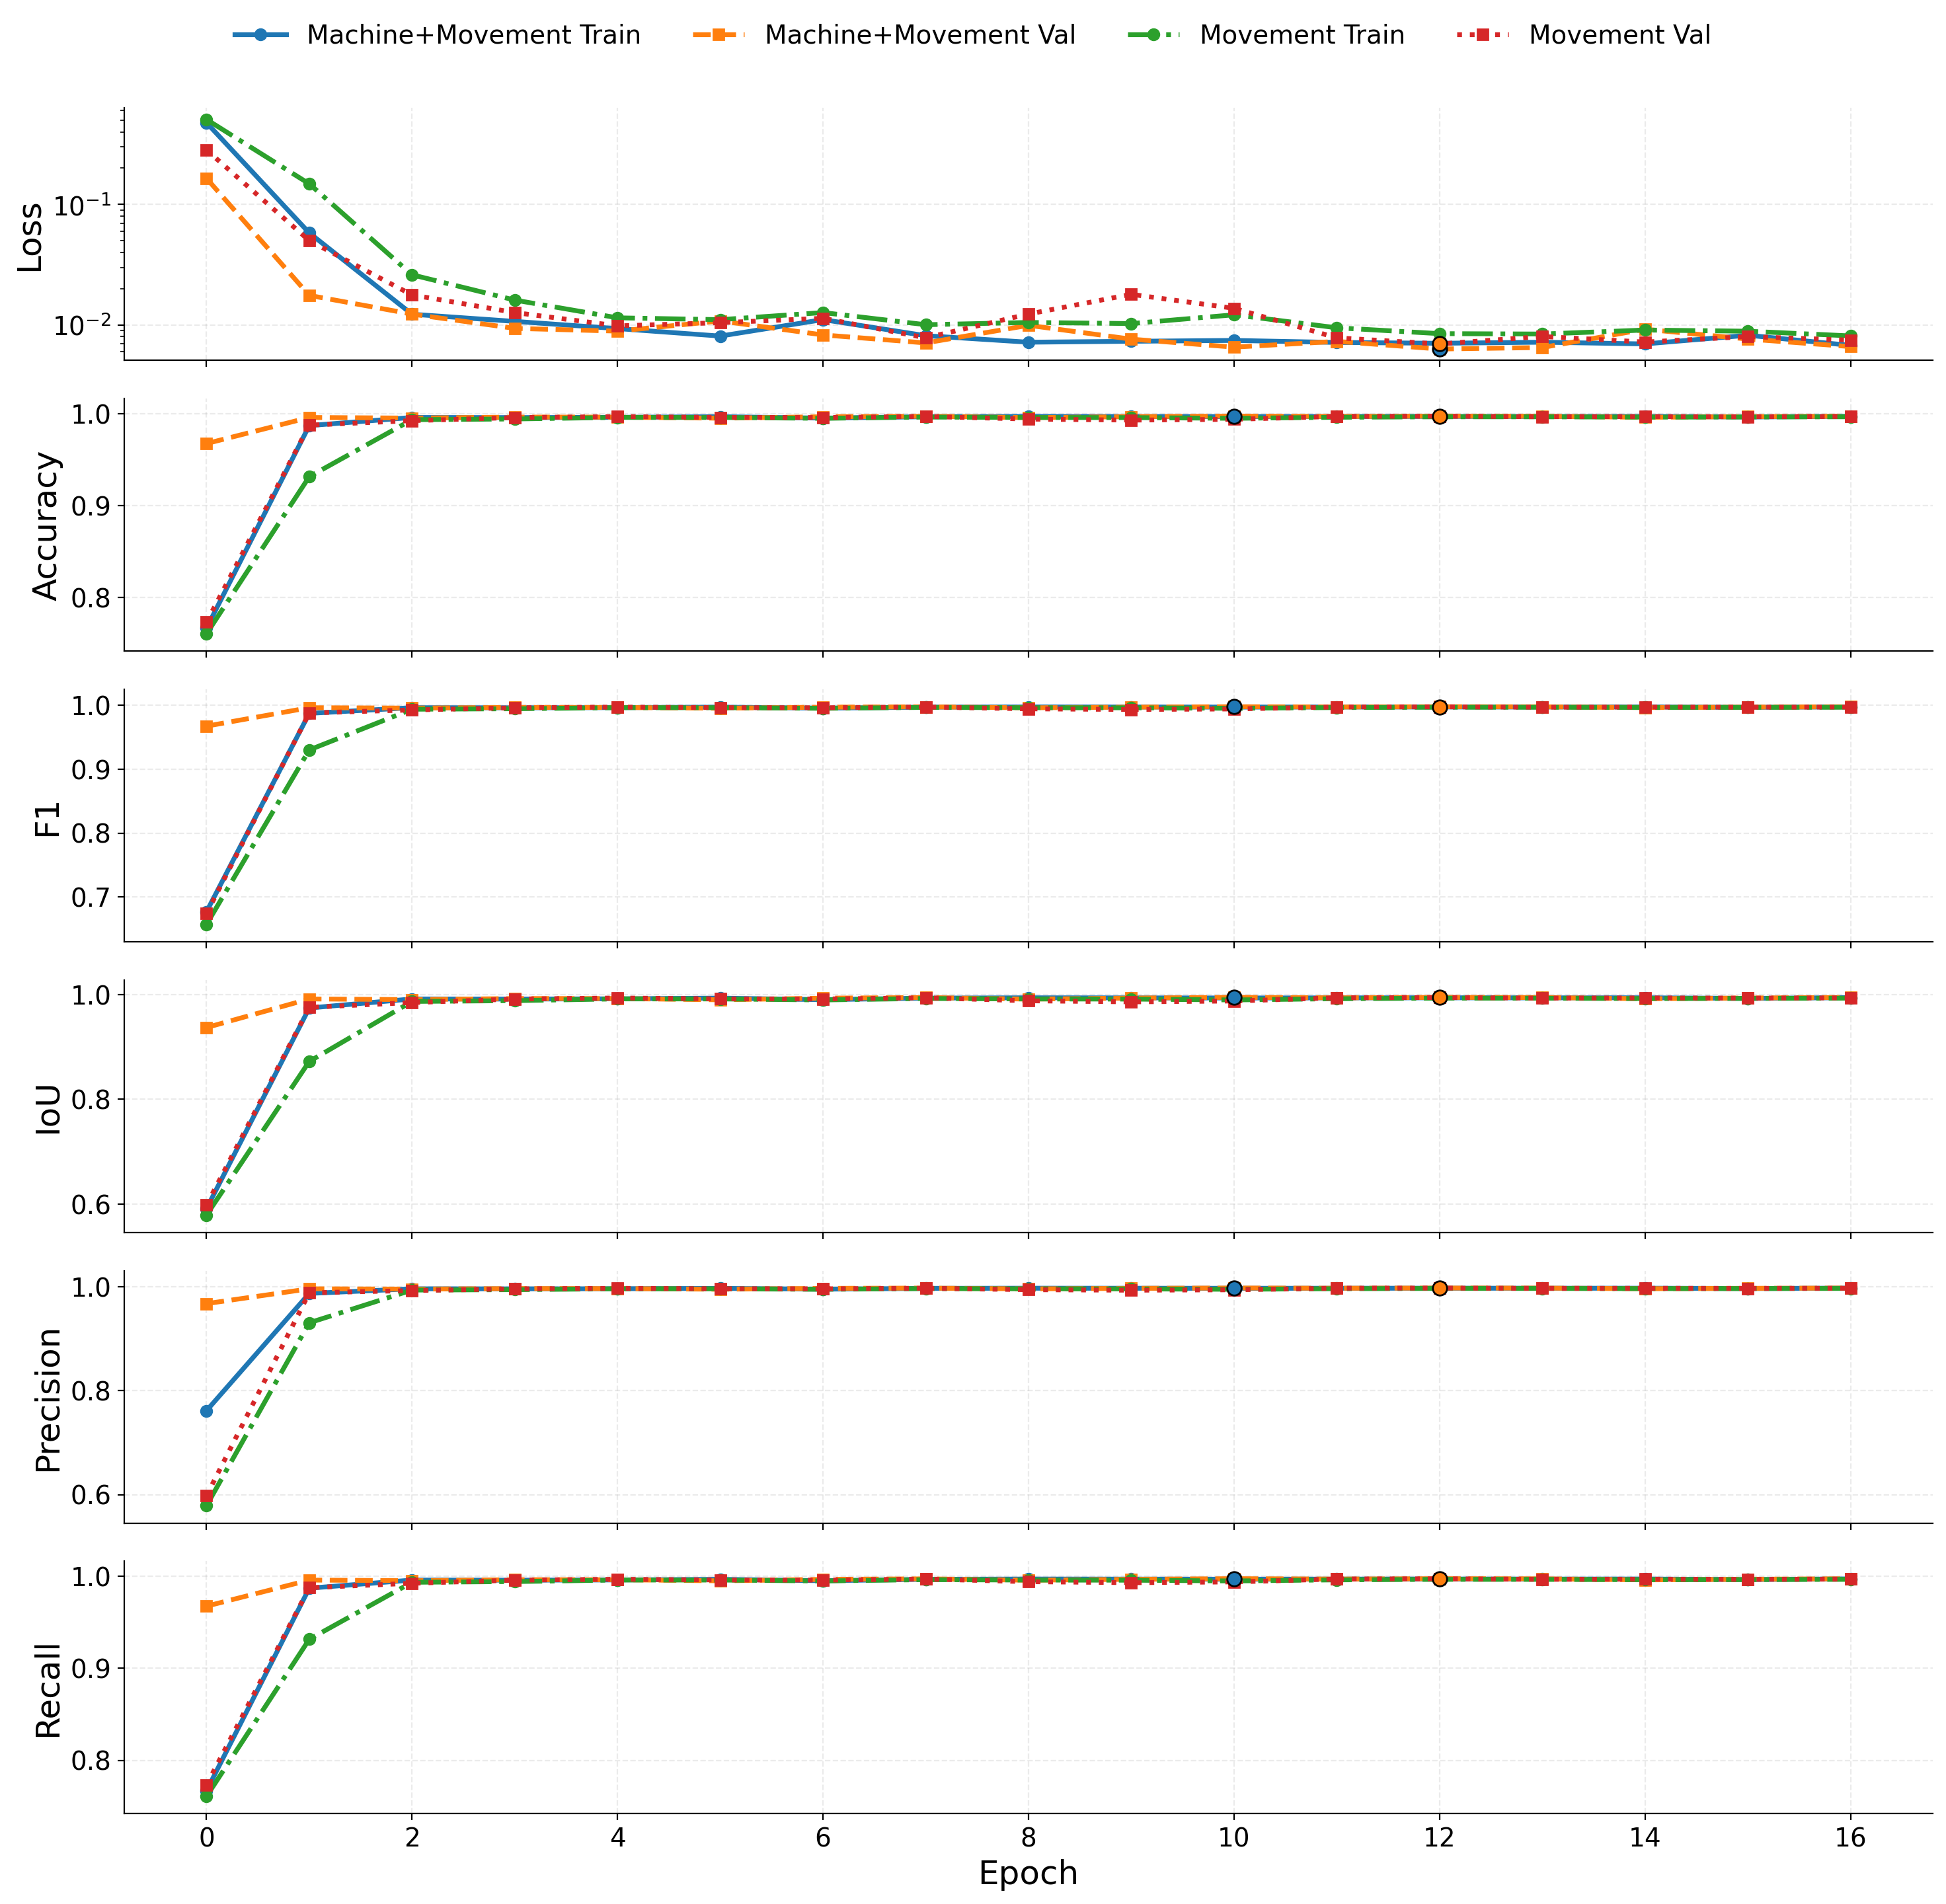

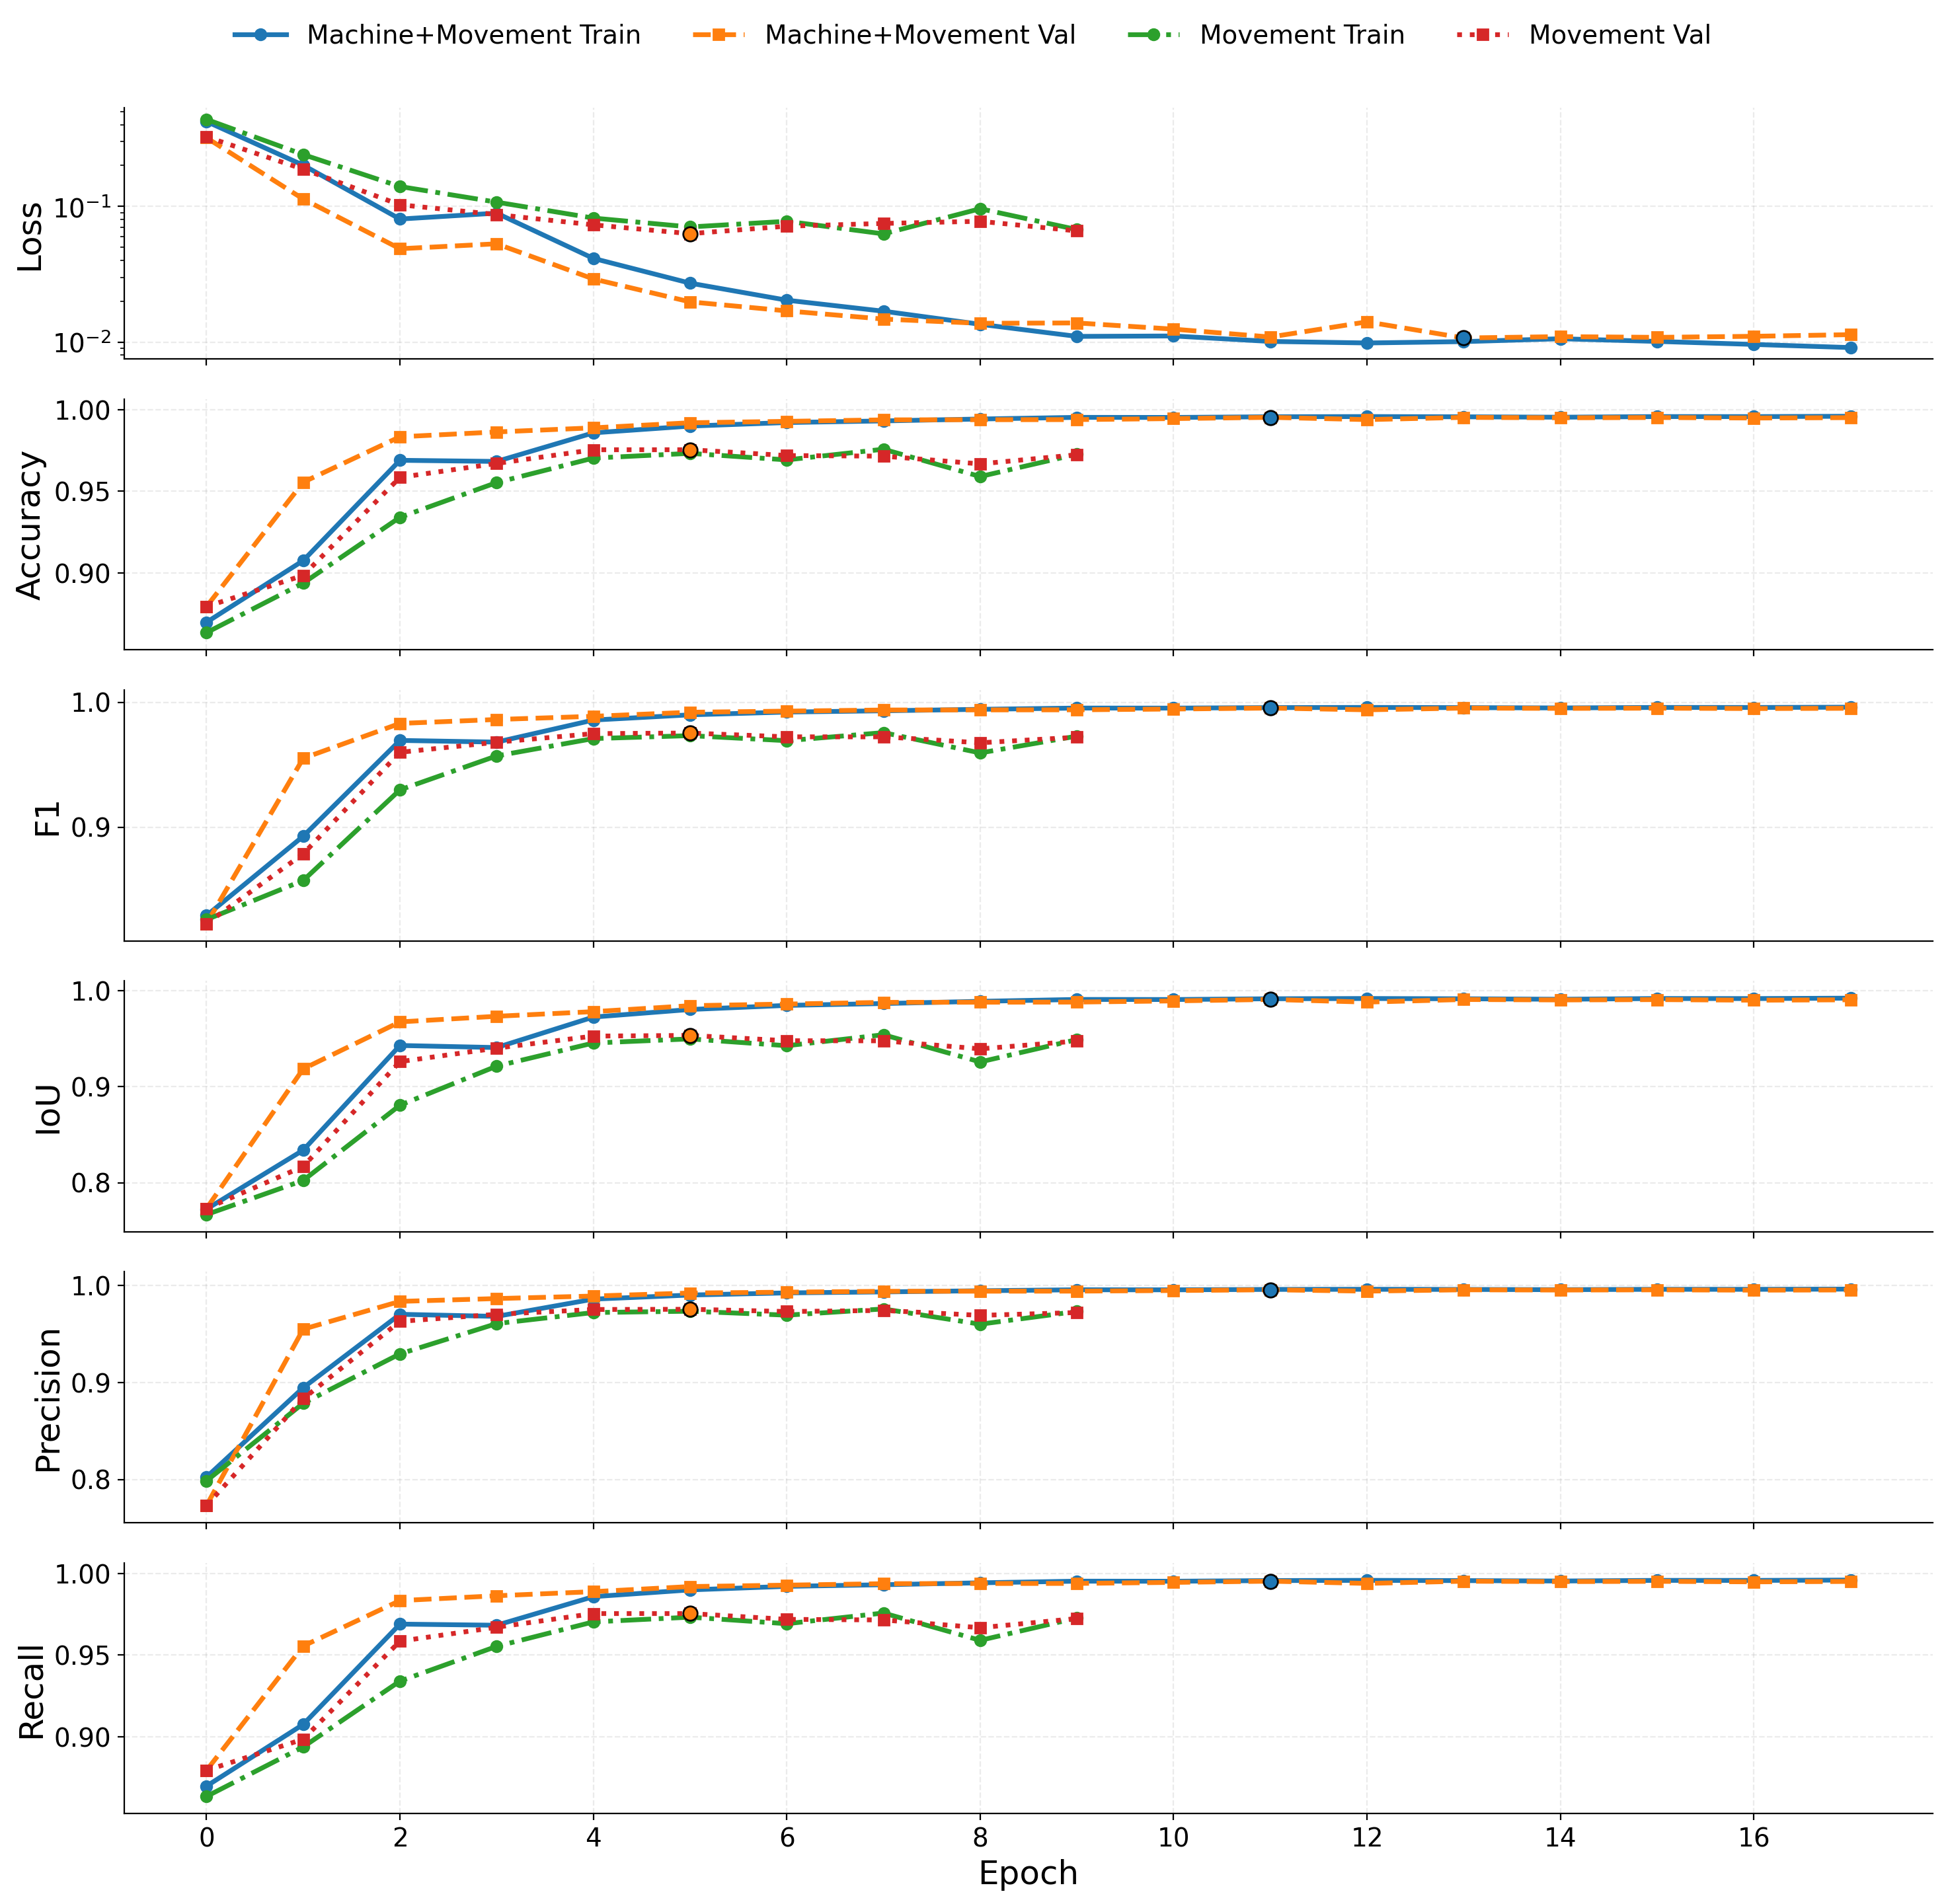

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# =====================================
# Paths
# =====================================
root_dir = "results/activity_recognition"

experiment_folders = {
    "Machine+Movement": os.path.join(root_dir, "machine_and_movement"),
    "Movement": os.path.join(root_dir, "movement"),
}

output_dir = root_dir

show_plot = True
save_plot = True
use_log_for_loss = True

preferred_order = ["loss", "acc", "f1", "iou", "precision", "recall"]

# =====================================
# Paper-style plotting configuration
# =====================================
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,

    "lines.linewidth": 2.6,
    "lines.markersize": 6,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# =====================================
# Helper functions
# =====================================
def pretty_metric_name(metric_name):
    name = metric_name.replace("train_", "").replace("val_", "")
    name = name.replace("_", " ").title()
    name = name.replace("Iou", "IoU")
    name = name.replace("Acc", "Accuracy")
    return name

def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

def metric_key_from_filename(file_name):
    left = file_name.split("-")[0]
    return left.replace("train_", "").lower()

# =====================================
# Load experiment data
# =====================================
all_experiments = {}
all_runs = set()
all_metric_keys = set()

for exp_name, exp_dir in experiment_folders.items():

    csv_files = glob.glob(os.path.join(exp_dir, "*.csv"))
    exp_data = {}

    for file_path in csv_files:

        file_name = os.path.basename(file_path).replace(".csv", "")
        parts = file_name.split("-")

        if len(parts) != 2:
            continue

        train_metric, val_metric = parts
        metric_key = metric_key_from_filename(file_name)

        df = pd.read_csv(file_path)

        required = ["step", "value", "metric", "Run"]
        if not all(c in df.columns for c in required):
            continue

        df["step"] = pd.to_numeric(df["step"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

        df = df.drop_duplicates()
        df = df.dropna(subset=["step", "value", "metric", "Run"])
        df = df[df["metric"].isin([train_metric, val_metric])]
        df = df.sort_values(["Run", "metric", "step"])

        if df.empty:
            continue

        all_runs.update(df["Run"].unique())
        all_metric_keys.add(metric_key)

        exp_data[metric_key] = {
            "metric_label": pretty_metric_name(train_metric),
            "train_metric": train_metric,
            "val_metric": val_metric,
            "df": df,
        }

    all_experiments[exp_name] = exp_data

sorted_metric_keys = [m for m in preferred_order if m in all_metric_keys]
sorted_metric_keys += sorted([m for m in all_metric_keys if m not in preferred_order])

sorted_runs = sorted(all_runs)

# =====================================
# Plot styles per experiment
# =====================================
experiment_styles = {
    "Machine+Movement": {"train": "-", "val": "--"},
    "Movement": {"train": "-.", "val": ":"},
}

# =====================================
# Create plots
# =====================================
for run_name in sorted_runs:

    n_metrics = len(sorted_metric_keys)

    fig, axes = plt.subplots(
        nrows=n_metrics,
        ncols=1,
        figsize=(15, 2.4 * n_metrics),
        sharex=True
    )

    if n_metrics == 1:
        axes = [axes]

    legend_handles = []
    legend_labels = []

    for ax, metric_key in zip(axes, sorted_metric_keys):

        metric_label = None
        values_for_axis = []

        for exp_name, exp_data in all_experiments.items():

            if metric_key not in exp_data:
                continue

            item = exp_data[metric_key]

            df = item["df"]
            train_metric = item["train_metric"]
            val_metric = item["val_metric"]
            metric_label = item["metric_label"]

            run_df = df[df["Run"] == run_name]

            train_df = run_df[run_df["metric"] == train_metric]
            val_df = run_df[run_df["metric"] == val_metric]

            style = experiment_styles[exp_name]

            if not train_df.empty:

                line, = ax.plot(
                    train_df["step"],
                    train_df["value"],
                    marker="o",
                    linestyle=style["train"],
                    label=f"{exp_name} Train"
                )

                if f"{exp_name} Train" not in legend_labels:
                    legend_handles.append(line)
                    legend_labels.append(f"{exp_name} Train")

                values_for_axis.extend(train_df["value"])

            if not val_df.empty:

                line, = ax.plot(
                    val_df["step"],
                    val_df["value"],
                    marker="s",
                    linestyle=style["val"],
                    label=f"{exp_name} Val"
                )

                if f"{exp_name} Val" not in legend_labels:
                    legend_handles.append(line)
                    legend_labels.append(f"{exp_name} Val")

                values_for_axis.extend(val_df["value"])

                # best validation point
                best_idx = val_df["value"].idxmin() if metric_key == "loss" else val_df["value"].idxmax()
                best_row = val_df.loc[best_idx]

                ax.scatter(
                    best_row["step"],
                    best_row["value"],
                    s=60,
                    edgecolor="black",
                    linewidth=1,
                    zorder=5
                )

        if metric_label:
            ax.set_ylabel(metric_label)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        if metric_key == "loss" and use_log_for_loss:
            ax.set_yscale("log")
        elif values_for_axis:
            y_min = min(values_for_axis)
            y_max = max(values_for_axis)
            margin = (y_max - y_min) * 0.08 if y_max > y_min else 0.01
            ax.set_ylim(y_min - margin, y_max + margin)

    # x-label only on bottom subplot
    axes[-1].set_xlabel("Epoch")

    # Global legend
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_plot:
        output_path = os.path.join(output_dir, f"training_metrics_{safe_name(run_name)}.pdf")
        plt.savefig(output_path, format="pdf", bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close()

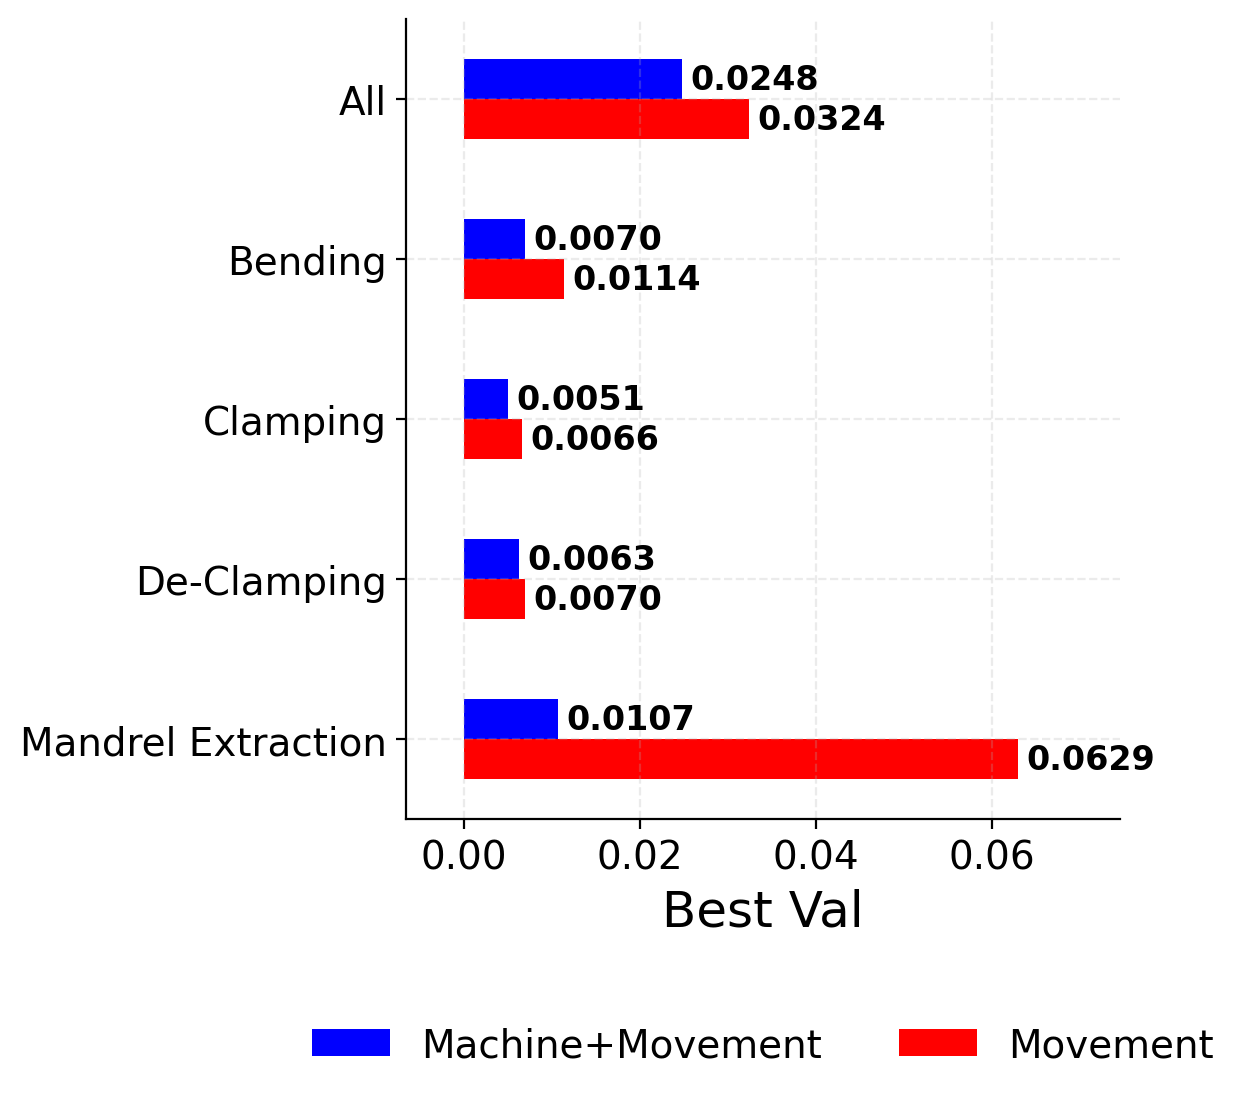

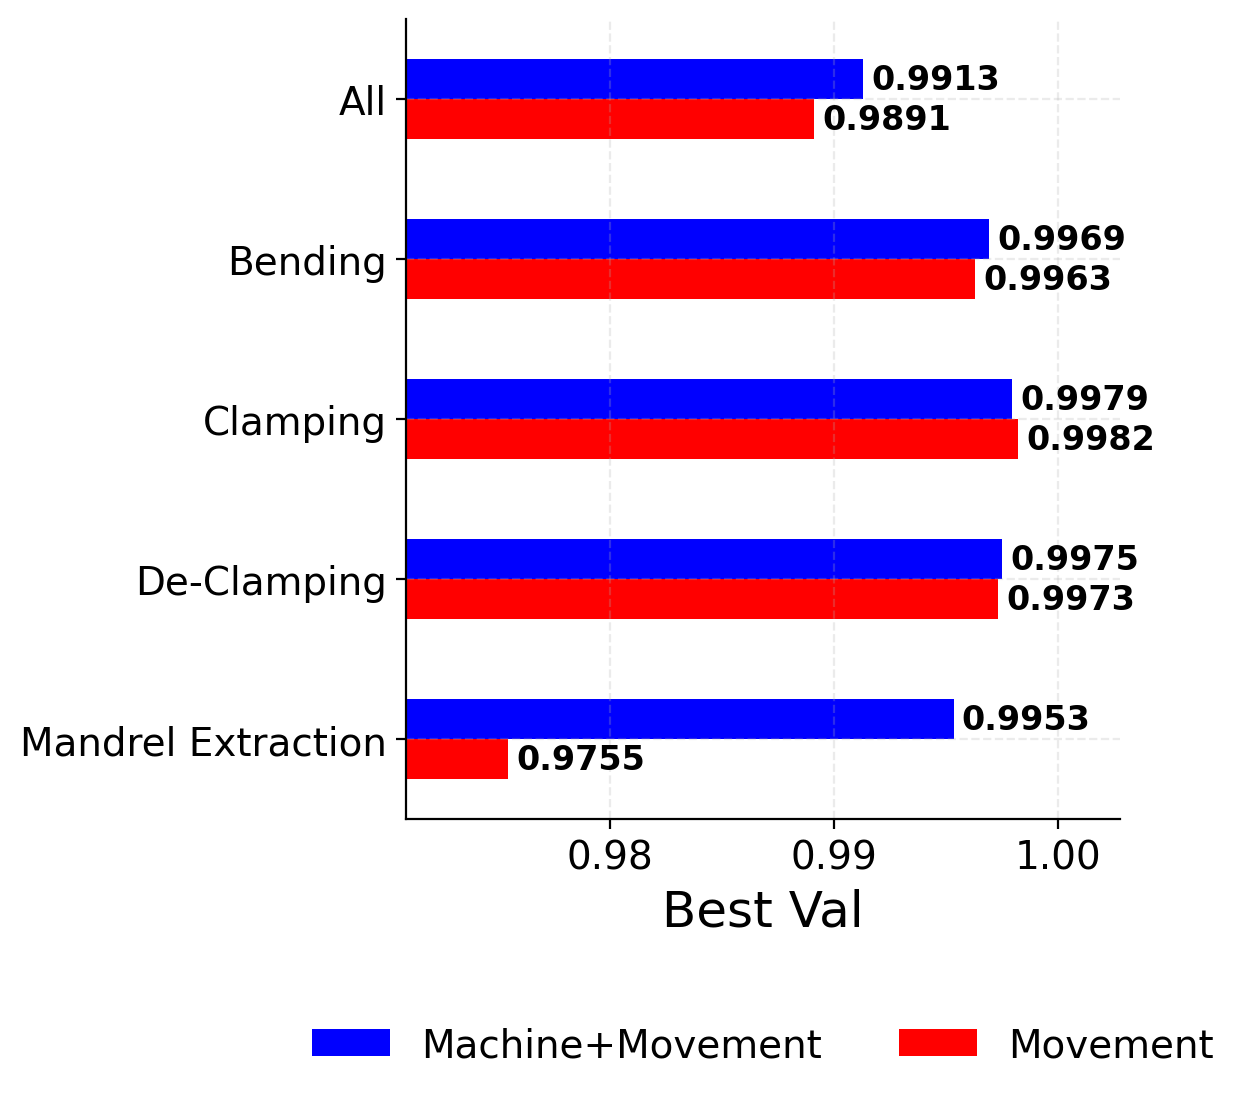

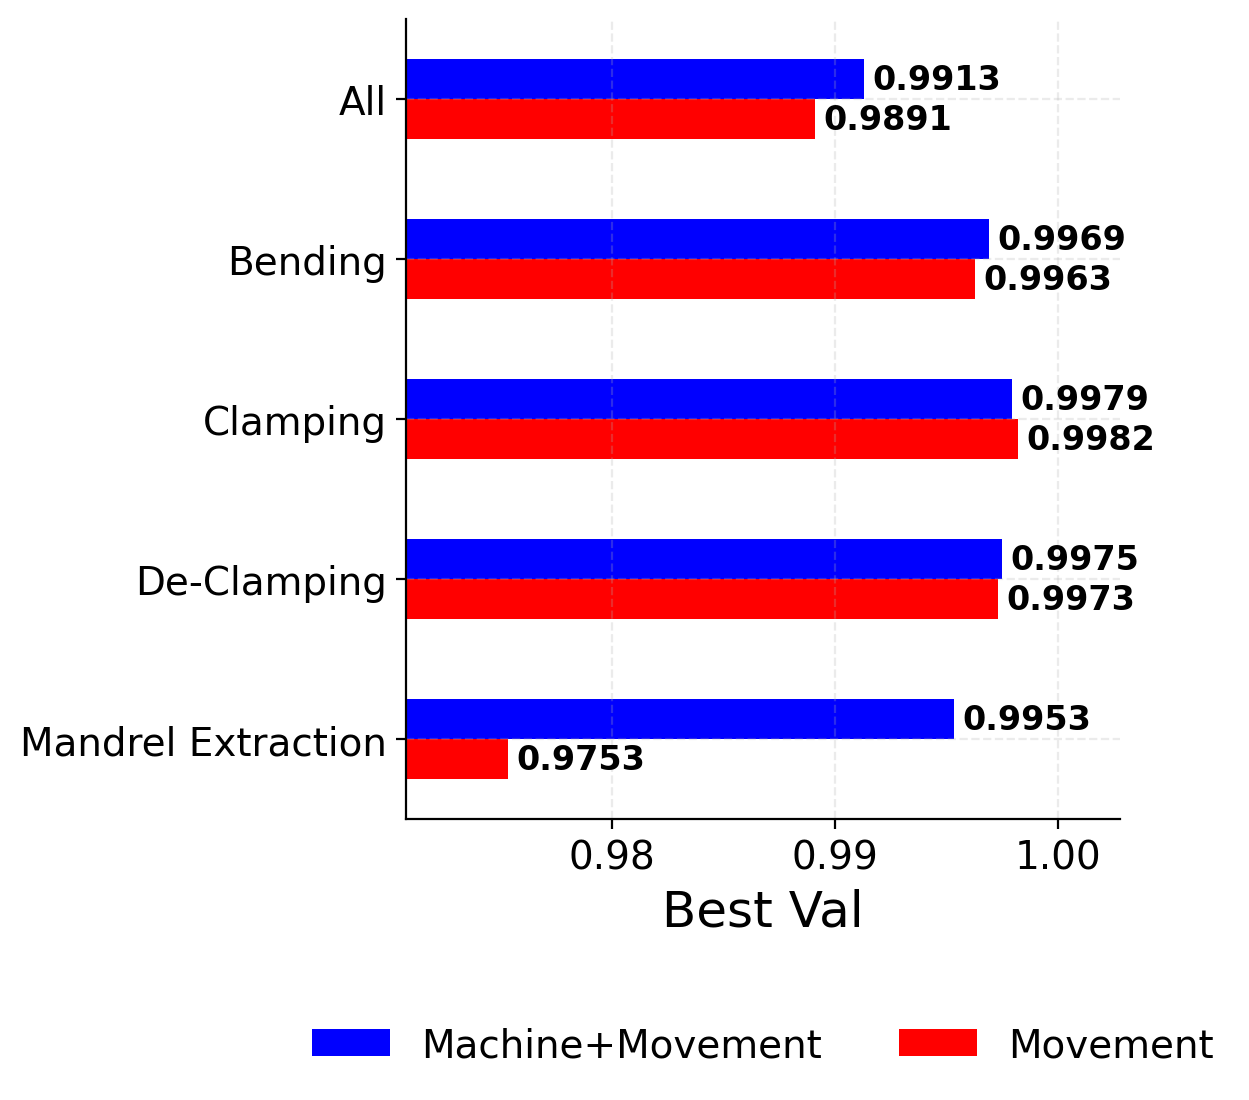

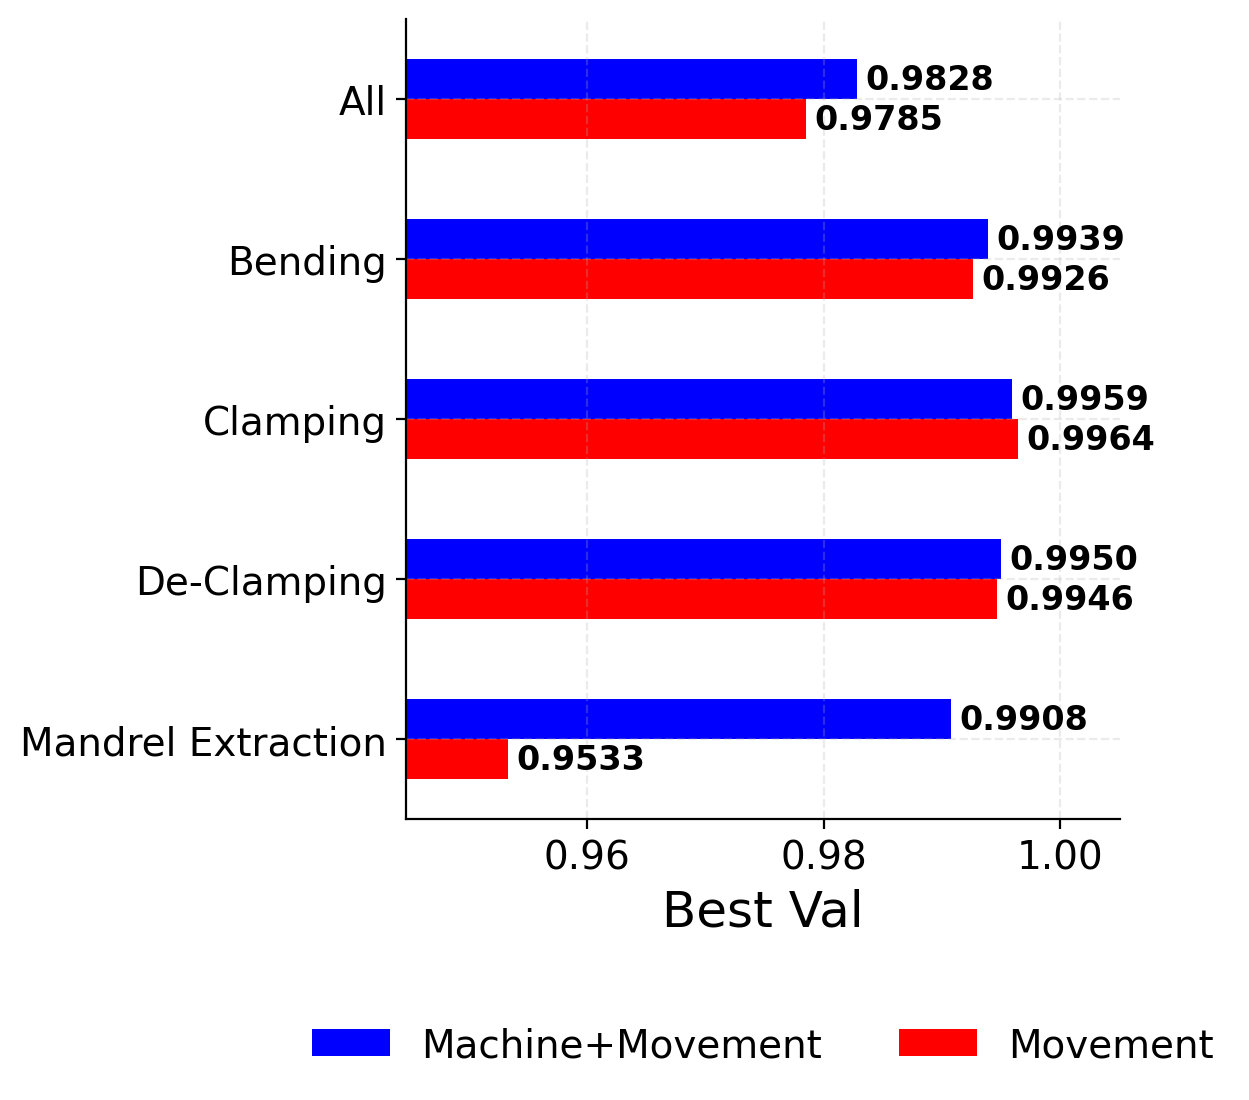

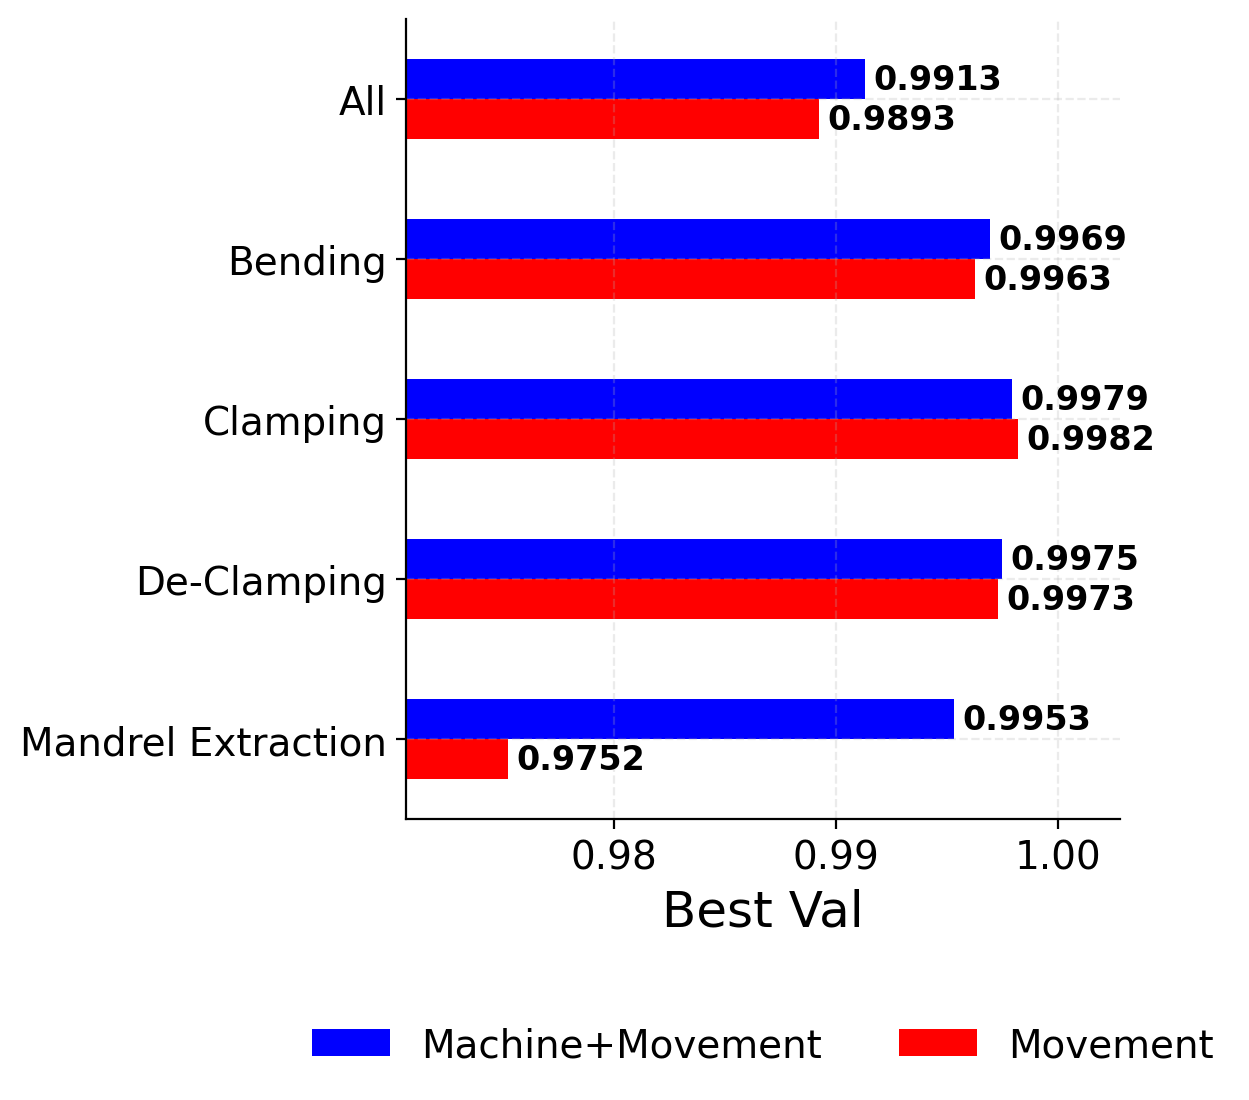

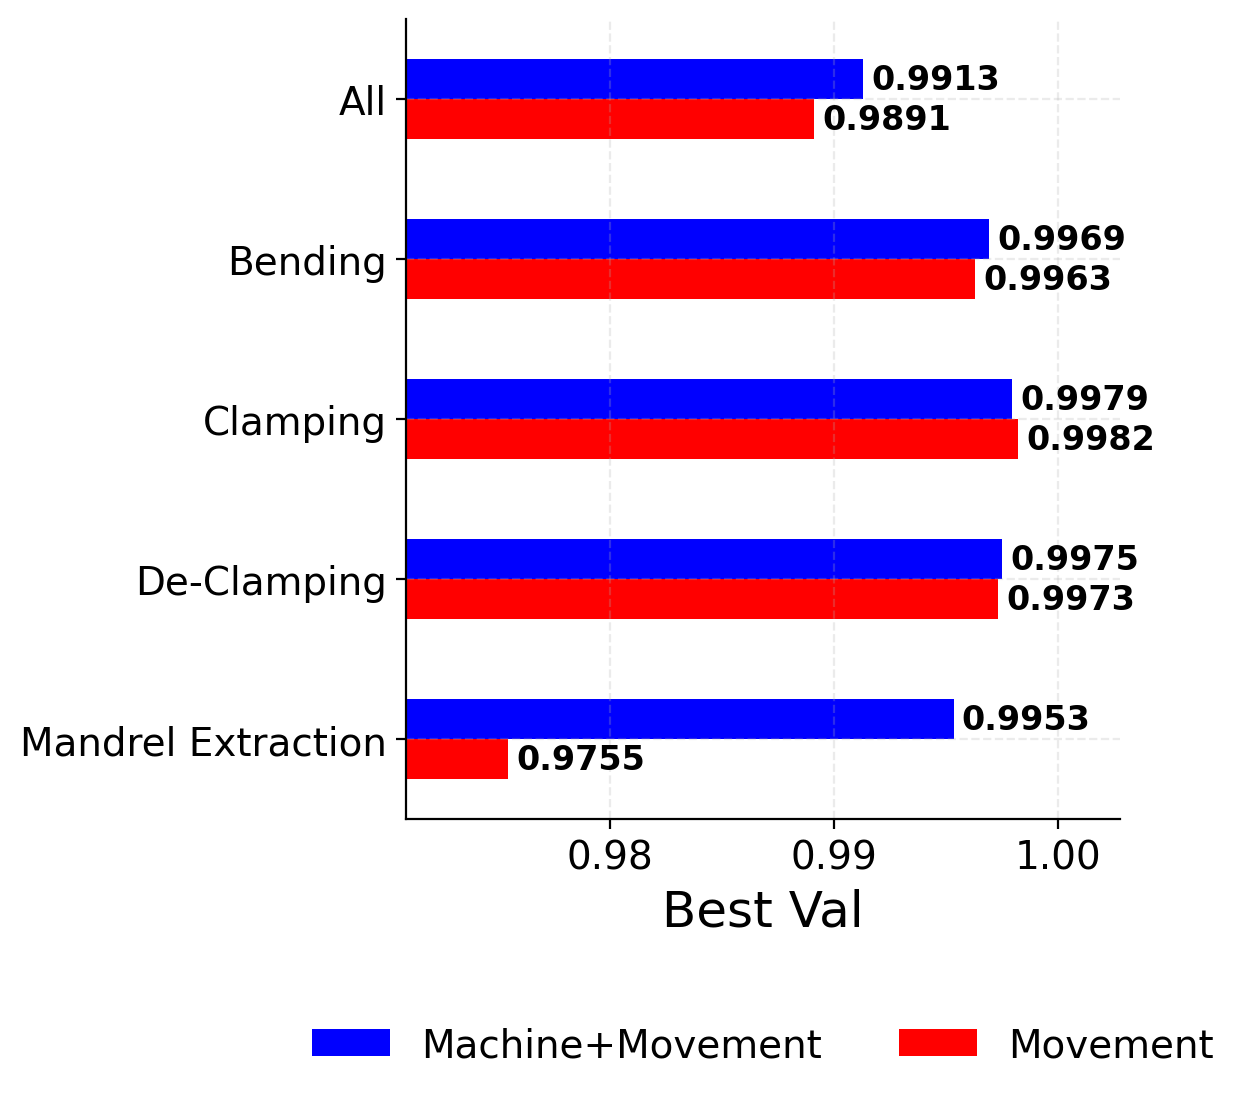

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# Paths
# =====================================
root_dir = "results/activity_recognition"
pattern = os.path.join(root_dir, "metrics_best_last_summary_*.csv")

output_dir = os.path.join(root_dir, "paper_comparison_plots")
os.makedirs(output_dir, exist_ok=True)

value_column = "Best Val"

process_part_order = [
    "All",
    "Bending",
    "Clamping",
    "De-Clamping",
    "Mandrel Extraction",
]

metric_order = [
    "Loss",
    "Accuracy",
    "F1",
    "IoU",
    "Precision",
    "Recall",
]

# =====================================
# Plot style
# =====================================
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# =====================================
# Helpers
# =====================================
def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

def extract_process_part(file_path):
    name = os.path.basename(file_path)
    name = name.replace("metrics_best_last_summary_", "")
    name = name.replace(".csv", "")
    name = name.replace("_", " ")
    return name

# =====================================
# Load CSV files
# =====================================
dfs = []

for file_path in glob.glob(pattern):

    df = pd.read_csv(file_path)

    if df.empty:
        continue

    process_part = extract_process_part(file_path)
    df["Process Part"] = process_part
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data[value_column] = pd.to_numeric(data[value_column], errors="coerce")

data = data.dropna(subset=["Process Part","Experiment","Metric",value_column])

# Order process parts
available_parts = data["Process Part"].unique().tolist()
final_part_order = [p for p in process_part_order if p in available_parts]
final_part_order += [p for p in available_parts if p not in final_part_order]

# Order metrics
available_metrics = data["Metric"].unique().tolist()
final_metric_order = [m for m in metric_order if m in available_metrics]
final_metric_order += [m for m in available_metrics if m not in final_metric_order]

# =====================================
# Plot
# =====================================
for metric in final_metric_order:

    sub = data[data["Metric"] == metric]

    pivot = sub.pivot_table(
        index="Process Part",
        columns="Experiment",
        values=value_column,
        aggfunc="first"
    )

    pivot = pivot.reindex([p for p in final_part_order if p in pivot.index])

    fig, ax = plt.subplots(figsize=(6,6))

    # Horizontal bar plot with thinner bars
    pivot.plot(
        kind="barh",
        ax=ax,
        color=["blue","red"],
        width=0.5
    )

    # ---------------------------------
    # Zoom X-axis (metric axis)
    # ---------------------------------
    xmin = pivot.min().min()
    xmax = pivot.max().max()

    margin = (xmax - xmin) * 0.2
    if margin == 0:
        margin = xmax * 0.01

    ax.set_xlim(xmin - margin, xmax + margin)

    ax.set_ylabel("")
    ax.set_xlabel(value_column)

    # keep first element on top
    ax.invert_yaxis()

    # ---------------------------------
    # Annotate values
    # ---------------------------------
    for container in ax.containers:

        labels = ax.bar_label(
            container,
            fmt="%.4f",
            padding=3
        )

        for label in labels:
            label.set_fontsize(12)
            label.set_fontweight("bold")

    # ---------------------------------
    # Legend outside
    # ---------------------------------
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        f"zoom_comparison_{safe_name(metric)}.pdf"
    )

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()